# High Tide Inc. (NASDAQ: HITI) — Financial Model

*Fiscal year ends October 31. All monetary values in C$ thousands unless stated otherwise.*

**Key driver**: Store-count growth + same-store sales momentum + margin expansion via Cabanalytics / white-label mix shift.

In [1]:
# ============================================================
# CELL GROUP 1: SETUP & DATA INPUT
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# Color palette (matches REAX model)
COLORS = {
    'primary': '#1a73e8',
    'secondary': '#34a853',
    'accent': '#ea4335',
    'neutral': '#5f6368',
    'light': '#a8d5e2',
    'gold': '#f9ab00',
}

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ── Annual Income Statement (C$ thousands) ──────────────────
# FY ends October 31. Data from audited filings / StockAnalysis.

income_stmt = pd.DataFrame({
    'Revenue':              [487_700, 522_310, 593_990],
    'COGS':                 [356_400, 379_800, 439_600],
    'Gross_Profit':         [131_300, 142_500, 153_500],
    'SGA_Expense':          [133_200, 107_800, 128_200],   # selling, general & admin
    'Impairment':           [ 30_000,  15_000,  30_000],   # goodwill/intangible impairments (est.)
    'Other_OpEx':           [  5_000,   9_400,   4_300],
    'Total_OpEx':           [168_200, 132_200, 162_500],
    'Operating_Income':     [-36_900,  10_400,  -9_000],
    'Finance_Expense':      [ -3_500,  -7_500, -12_000],   # interest on leases + debt
    'Other_Gains_Losses':   [  1_100,  -6_700, -30_400],   # derivative FV, FX, other
    'Pretax_Income':        [-39_300,  -3_800, -51_400],
    'Tax':                  [      0,    -500,       0],
    'Net_Income':           [-39_300,  -4_300, -51_400],
    'SBC':                  [  5_030,   2_980,   3_920],
    'DA':                   [ 32_760,  25_390,  24_310],
    'Adj_EBITDA':           [ 30_600,  38_340,  38_210],
    'Shares_Basic_K':       [ 74_200,  79_600,  82_200],
    'Shares_Diluted_K':     [ 74_200,  79_600,  82_200],   # anti-dilutive, so same as basic
}, index=[2023, 2024, 2025])
income_stmt.index.name = 'FY'

print('Annual Income Statement (C$K)')
print('='*60)
display(income_stmt[['Revenue','Gross_Profit','Operating_Income',
                     'Net_Income','Adj_EBITDA','DA','SBC']].T)

Annual Income Statement (C$K)


FY,2023,2024,2025
Revenue,487700,522310,593990
Gross_Profit,131300,142500,153500
Operating_Income,-36900,10400,-9000
Net_Income,-39300,-4300,-51400
Adj_EBITDA,30600,38340,38210
DA,32760,25390,24310
SBC,5030,2980,3920


In [3]:
# ── Expense Breakdown (C$ thousands) ────────────────────────
# Derived from annual filings; some line items estimated

expense_detail = pd.DataFrame({
    'Salaries_Wages':     [ 56_500,  65_300,  74_200],   # ~12% of rev
    'Rent_Occupancy':     [ 28_000,  30_000,  33_000],   # lease-related costs beyond ROU
    'Marketing':          [  4_000,   3_500,   4_500],
    'Professional_Fees':  [  5_500,   5_000,   5_500],
    'Technology':         [  3_000,   4_000,   5_000],
    'Insurance':          [  2_200,   2_500,   3_000],
    'Other_GA':           [ 34_000,  22_500,  37_000],   # includes impairments, other
    'Depreciation':       [ 32_760,  25_390,  24_310],
    'SBC':                [  5_030,   2_980,   3_920],
}, index=[2023, 2024, 2025])
expense_detail.index.name = 'FY'

# Expense as % of revenue
expense_pct = expense_detail.div(income_stmt['Revenue'], axis=0) * 100

print('Expense Breakdown (C$K)')
print('='*60)
display(expense_detail.T)
print('\nAs % of Revenue:')
display(expense_pct.T.round(1))

Expense Breakdown (C$K)


FY,2023,2024,2025
Salaries_Wages,56500,65300,74200
Rent_Occupancy,28000,30000,33000
Marketing,4000,3500,4500
Professional_Fees,5500,5000,5500
Technology,3000,4000,5000
Insurance,2200,2500,3000
Other_GA,34000,22500,37000
Depreciation,32760,25390,24310
SBC,5030,2980,3920



As % of Revenue:


FY,2023,2024,2025
Salaries_Wages,11.6,12.5,12.5
Rent_Occupancy,5.7,5.7,5.6
Marketing,0.8,0.7,0.8
Professional_Fees,1.1,1.0,0.9
Technology,0.6,0.8,0.8
Insurance,0.5,0.5,0.5
Other_GA,7.0,4.3,6.2
Depreciation,6.7,4.9,4.1
SBC,1.0,0.6,0.7


In [4]:
# ── Balance Sheet (C$ thousands) ────────────────────────────

balance_sheet = pd.DataFrame({
    'Cash':                 [ 30_120,  47_270,  47_880],
    'Accounts_Receivable':  [  8_500,   9_200,  12_500],
    'Inventory':            [ 22_000,  20_000,  25_000],
    'Other_Current':        [  8_030,   9_320,  51_510],   # FY2025 includes Remexian-related
    'Total_Current_Assets': [ 68_650,  85_790, 136_890],
    'PP_E':                 [ 15_000,  14_000,  16_000],
    'ROU_Assets':           [ 55_000,  50_000,  65_000],   # right-of-use lease assets
    'Intangibles_Goodwill': [ 85_000,  85_000,  95_000],   # net of impairments
    'Other_NonCurrent':     [  9_750,  11_410,  36_170],   # investments, Remexian
    'Total_Assets':         [233_400, 246_210, 349_060],
    'Accounts_Payable':     [ 18_000,  16_000,  22_000],
    'Current_Lease_Liab':   [ 12_000,  11_000,  14_000],
    'Current_Debt':         [ 13_000,  13_000,  18_000],
    'Other_Current_Liab':   [ 15_140,  21_480,  45_920],
    'Total_Current_Liab':   [ 58_140,  61_480,  99_920],
    'LT_Debt':              [ 12_510,   7_540,  42_320],   # includes sub debt facility
    'LT_Lease_Liab':        [ 22_000,  25_000,  48_000],   # grew with new stores
    'Other_LT_Liab':        [  7_090,   6_680,  56_040],   # derivatives, Remexian contingent
    'Total_Liabilities':    [ 99_740, 100_700, 246_280],
    'Share_Capital':        [280_000, 290_000, 305_000],
    'Retained_Earnings':    [-146_330, -144_490, -202_210],  # cumulative losses
    'Shareholders_Equity':  [133_670, 145_510, 102_790],
}, index=[2023, 2024, 2025])
balance_sheet.index.name = 'FY'

print('Balance Sheet (C$K)')
print('='*60)
display(balance_sheet[['Cash','Total_Current_Assets','Total_Assets',
                       'Total_Current_Liab','LT_Debt','Total_Liabilities',
                       'Shareholders_Equity']].T)

Balance Sheet (C$K)


FY,2023,2024,2025
Cash,30120,47270,47880
Total_Current_Assets,68650,85790,136890
Total_Assets,233400,246210,349060
Total_Current_Liab,58140,61480,99920
LT_Debt,12510,7540,42320
Total_Liabilities,99740,100700,246280
Shareholders_Equity,133670,145510,102790


In [5]:
# ── Cash Flow Statement (C$ thousands) ──────────────────────

cash_flow = pd.DataFrame({
    'Net_Income':           [-39_300,  -4_300, -51_400],
    'DA':                   [ 32_760,  25_390,  24_310],
    'SBC':                  [  5_030,   2_980,   3_920],
    'Impairments':          [ 25_000,  10_000,  28_000],
    'WC_Changes':           [ -2_830,   1_050,  13_040],
    'Operating_CF':         [ 20_660,  35_120,  17_870],
    'Capex':                [ -5_790,  -3_500,  -5_870],   # sustaining + new stores
    'Acquisitions':         [      0,       0, -36_000],   # Remexian
    'Other_Investing':      [  1_200,  -1_500,  -2_000],
    'Investing_CF':         [ -4_590,  -5_000, -43_870],
    'Debt_Proceeds':        [  5_000,  15_000,  40_000],
    'Debt_Repayments':      [-10_000, -13_000, -15_000],
    'Lease_Payments':       [ -9_000, -10_500, -12_000],
    'Equity_Issuance':      [  5_000,   5_000,   8_000],
    'Other_Financing':      [ -3_000,  -3_000,  -4_390],
    'Financing_CF':         [-12_000,  -6_500,  16_610],
    'Free_Cash_Flow':       [ 14_870,  31_620,  12_000],
}, index=[2023, 2024, 2025])
cash_flow.index.name = 'FY'

print('Cash Flow Statement (C$K)')
print('='*60)
display(cash_flow[['Operating_CF','Capex','Free_Cash_Flow',
                   'Investing_CF','Financing_CF']].T)

Cash Flow Statement (C$K)


FY,2023,2024,2025
Operating_CF,20660,35120,17870
Capex,-5790,-3500,-5870
Free_Cash_Flow,14870,31620,12000
Investing_CF,-4590,-5000,-43870
Financing_CF,-12000,-6500,16610


In [6]:
# ── Quarterly KPI Data ──────────────────────────────────────
# Store count at quarter-end, quarterly revenue, adj EBITDA

quarterly_kpi = pd.DataFrame({
    'Revenue_K': [
        # FY2023 Q1-Q4 (quarters ending Jan/Apr/Jul/Oct 2023)
        118_080, 118_140, 124_350, 127_110,
        # FY2024 Q1-Q4
        128_070, 124_260, 131_690, 138_300,
        # FY2025 Q1-Q4
        142_460, 137_800, 149_690, 164_030,
        # FY2026 Q1-Q2 (Q1 implied from H1 minus Q2; Q2 reported)
        178_300, 179_300,
    ],
    'Stores': [
        # FY2023
        140, 148, 155, 163,
        # FY2024
        168, 175, 183, 191,
        # FY2025
        194, 200, 207, 218,
        # FY2026 Q1-Q2
        222, 228,
    ],
    'Adj_EBITDA_K': [
        # FY2023 (estimated from annual)
        6_200, 7_000, 9_000, 8_400,
        # FY2024
        9_700, 10_900, 9_600, 8_200,
        # FY2025
        7_100, 8_100, 10_600, 12_400,
        # FY2026 Q1-Q2 (implied Q1; reported Q2)
        11_500, 13_900,
    ],
    'SSSG_pct': [
        # FY2023 (estimated)
        15.0, 12.0, 8.0, 5.0,
        # FY2024
        3.5, 2.0, 1.5, 0.4,
        # FY2025
        4.0, 3.5, 4.5, 5.5,
        # FY2026 Q1-Q2 (Q2 reported -1.2%; Q1 est.)
        0.5, -1.2,
    ],
    'Cabana_Club_Members_K': [
        # FY2023
        900, 1000, 1100, 1200,
        # FY2024
        1300, 1420, 1550, 1720,
        # FY2025
        1900, 2100, 2300, 2500,
        # FY2026 Q1-Q2
        2570, 2650,
    ],
}, index=pd.MultiIndex.from_tuples([
    (2023, 'Q1'), (2023, 'Q2'), (2023, 'Q3'), (2023, 'Q4'),
    (2024, 'Q1'), (2024, 'Q2'), (2024, 'Q3'), (2024, 'Q4'),
    (2025, 'Q1'), (2025, 'Q2'), (2025, 'Q3'), (2025, 'Q4'),
    (2026, 'Q1'), (2026, 'Q2'),
], names=['FY', 'Quarter']))

# Derived metrics
quarterly_kpi['Rev_Per_Store_K'] = (quarterly_kpi['Revenue_K'] /
                                     quarterly_kpi['Stores']).round(0)
quarterly_kpi['Rev_Per_Store_Annualized_K'] = (quarterly_kpi['Rev_Per_Store_K'] * 4).round(0)
quarterly_kpi['Gross_Margin_pct'] = [
    27.0, 27.0, 27.0, 26.0,  # FY2023
    27.0, 27.0, 27.0, 26.0,  # FY2024
    27.0, 27.0, 27.0, 26.0,  # FY2025
    24.9, 27.0,              # FY2026 Q1-Q2 (Q2 reported 27%)
]

print('Quarterly KPI Data')
print('='*60)
display(quarterly_kpi)

Quarterly KPI Data


Revenue_K  Stores  Adj_EBITDA_K  SSSG_pct  \
FY   Quarter                                              
2023 Q1          118080     140          6200      15.0   
     Q2          118140     148          7000      12.0   
     Q3          124350     155          9000       8.0   
     Q4          127110     163          8400       5.0   
2024 Q1          128070     168          9700       3.5   
     Q2          124260     175         10900       2.0   
     Q3          131690     183          9600       1.5   
     Q4          138300     191          8200       0.4   
2025 Q1          142460     194          7100       4.0   
     Q2          137800     200          8100       3.5   
     Q3          149690     207         10600       4.5   
     Q4          164030     218         12400       5.5   
2026 Q1          178300     222         11500       0.5   
     Q2          179300     228         13900      -1.2   

              Cabana_Club_Members_K  Rev_Per_Store_K  \
FY   Quarter                                           
2023 Q1                         900            843.0   
     Q2                        1000            798.0   
     Q3                        1100            802.0   
     Q4                        1200            780.0   
2024 Q1                        1300            762.0   
     Q2                        1420            710.0   
     Q3                        1550            720.0   
     Q4                        1720            724.0   
2025 Q1                        1900            734.0   
     Q2                        2100            689.0   
     Q3                        2300            723.0   
     Q4                        2500            752.0   
2026 Q1                        2570            803.0   
     Q2                        2650            786.0   

              Rev_Per_Store_Annualized_K  Gross_Margin_pct  
FY   Quarter                                                
2023 Q1                           3372.0              27.0  
     Q2                           3192.0              27.0  
     Q3                           3208.0              27.0  
     Q4                           3120.0              26.0  
2024 Q1                           3048.0              27.0  
     Q2                           2840.0              27.0  
     Q3                           2880.0              27.0  
     Q4                           2896.0              26.0  
2025 Q1                           2936.0              27.0  
     Q2                           2756.0              27.0  
     Q3                           2892.0              27.0  
     Q4                           3008.0              26.0  
2026 Q1                           3212.0              24.9  
     Q2                           3144.0              27.0

In [7]:
# ── Segment Data (C$ thousands) ─────────────────────────────
# Retail (Canna Cabana), E-commerce/Accessories, Data/Advertising, Germany

segment_data = pd.DataFrame({
    'Retail_Revenue':       [450_000, 490_000, 548_000],
    'Retail_Gross_Profit':  [112_000, 127_000, 139_000],
    'Retail_EBITDA':        [ 32_000,  40_000,  44_000],
    'Ecomm_Revenue':        [ 22_000,  17_000,  14_000],
    'Ecomm_Gross_Profit':   [  9_000,   7_000,   4_500],
    'Ecomm_EBITDA':         [ -5_000,  -3_000,  -7_000],   # includes impairments
    'Data_Adv_Revenue':     [  8_000,  10_000,  13_100],    # Cabanalytics + ads
    'Data_Adv_Gross_Profit':[  6_000,   7_500,  10_000],
    'Data_Adv_EBITDA':      [  3_600,   5_340,   7_210],
    'Germany_Revenue':      [      0,      0,   5_000],     # partial Q4 only
    'Germany_Gross_Profit':  [      0,      0,   1_500],
    'Germany_EBITDA':       [      0,      0,    -500],
    'Other_Revenue':        [  7_700,   5_310,  13_890],
    'Other_EBITDA':         [      0,  -4_000,  -5_500],
}, index=[2023, 2024, 2025])
segment_data.index.name = 'FY'

# Compute segment mix
total_rev = income_stmt['Revenue']
for seg in ['Retail', 'Ecomm', 'Data_Adv', 'Germany']:
    segment_data[f'{seg}_Pct'] = (segment_data[f'{seg}_Revenue'] / total_rev * 100).round(1)

print('Segment Data (C$K)')
print('='*60)
cols = ['Retail_Revenue','Retail_Pct','Ecomm_Revenue','Ecomm_Pct',
        'Data_Adv_Revenue','Data_Adv_Pct','Germany_Revenue','Germany_Pct']
display(segment_data[cols].T)

Segment Data (C$K)


FY,2023,2024,2025
Retail_Revenue,450000.0,490000.0,548000.0
Retail_Pct,92.3,93.8,92.3
Ecomm_Revenue,22000.0,17000.0,14000.0
Ecomm_Pct,4.5,3.3,2.4
Data_Adv_Revenue,8000.0,10000.0,13100.0
Data_Adv_Pct,1.6,1.9,2.2
Germany_Revenue,0.0,0.0,5000.0
Germany_Pct,0.0,0.0,0.8


# Cell Group 2: Historical Analysis Dashboard

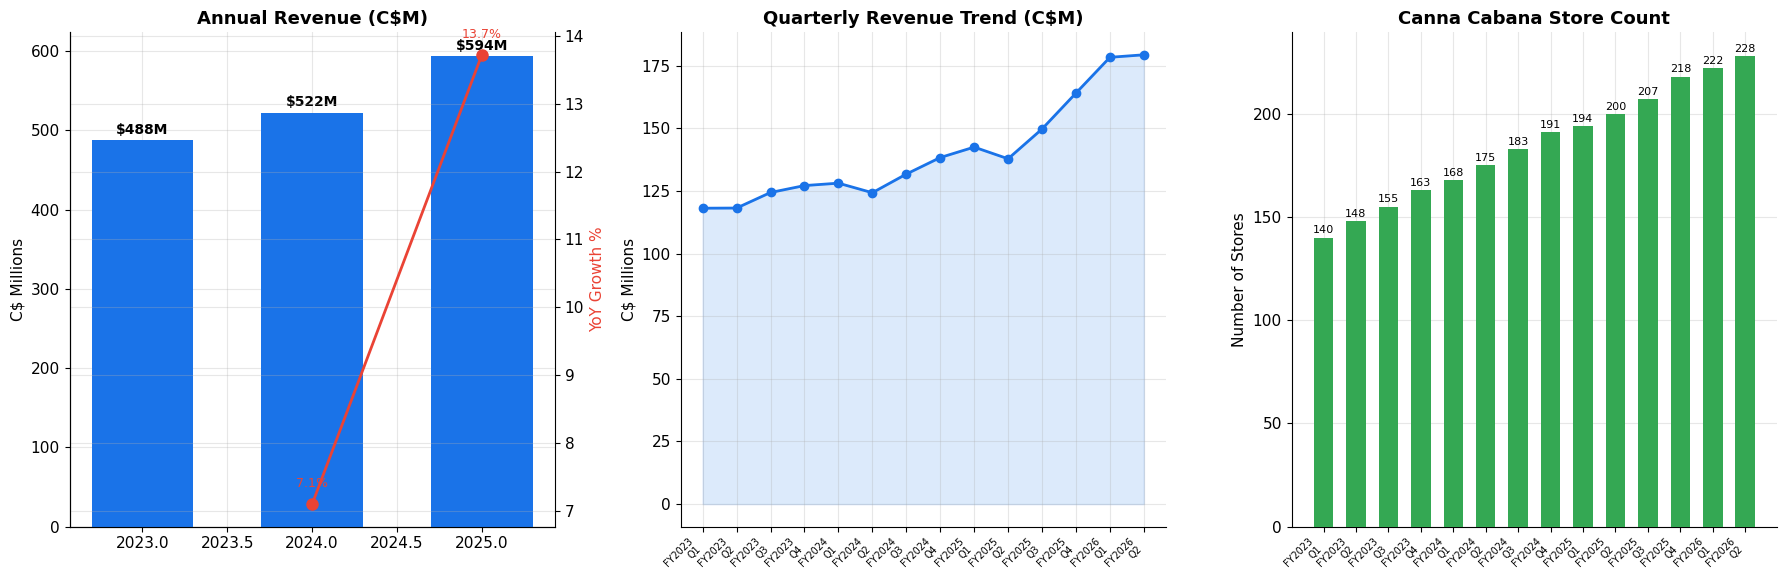


Revenue CAGR FY2023-FY2025: 10.4%
Store count growth FY2023-FY2025: 55 stores (+34%)


In [8]:
# ============================================================
# CELL GROUP 2: HISTORICAL ANALYSIS — Revenue & Growth
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- 1. Annual Revenue & Growth ---
ax = axes[0]
years = income_stmt.index
rev = income_stmt['Revenue'] / 1000  # C$M
bars = ax.bar(years, rev, color=COLORS['primary'], width=0.6, zorder=3)
ax.set_title('Annual Revenue (C$M)', fontsize=13, fontweight='bold')
ax.set_ylabel('C$ Millions')
for bar, val in zip(bars, rev):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'${val:.0f}M', ha='center', fontsize=10, fontweight='bold')
# Growth rate on secondary axis
ax2 = ax.twinx()
growth = income_stmt['Revenue'].pct_change() * 100
ax2.plot(years[1:], growth.dropna(), 'o-', color=COLORS['accent'],
         linewidth=2, markersize=8, zorder=4)
for x, y in zip(years[1:], growth.dropna()):
    ax2.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                 xytext=(0, 12), ha='center', fontsize=9, color=COLORS['accent'])
ax2.set_ylabel('YoY Growth %', color=COLORS['accent'])
ax2.spines['right'].set_visible(True)
ax2.spines['top'].set_visible(False)

# --- 2. Quarterly Revenue Trend ---
ax = axes[1]
q_labels = [f"FY{fy}\n{q}" for fy, q in quarterly_kpi.index]
q_rev = quarterly_kpi['Revenue_K'] / 1000
ax.plot(range(len(q_rev)), q_rev, 'o-', color=COLORS['primary'],
        linewidth=2, markersize=6, zorder=3)
ax.fill_between(range(len(q_rev)), q_rev, alpha=0.15, color=COLORS['primary'])
ax.set_xticks(range(len(q_rev)))
ax.set_xticklabels(q_labels, rotation=45, fontsize=7, ha='right')
ax.set_title('Quarterly Revenue Trend (C$M)', fontsize=13, fontweight='bold')
ax.set_ylabel('C$ Millions')

# --- 3. Store Count Growth ---
ax = axes[2]
stores = quarterly_kpi['Stores']
ax.bar(range(len(stores)), stores, color=COLORS['secondary'], width=0.6, zorder=3)
ax.set_xticks(range(len(stores)))
ax.set_xticklabels(q_labels, rotation=45, fontsize=7, ha='right')
ax.set_title('Canna Cabana Store Count', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Stores')
for i, v in enumerate(stores):
    ax.text(i, v + 2, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f'\nRevenue CAGR FY2023-FY2025: '
      f'{((income_stmt.loc[2025,"Revenue"]/income_stmt.loc[2023,"Revenue"])**(1/2)-1)*100:.1f}%')
print(f'Store count growth FY2023-FY2025: {218-163} stores (+{(218/163-1)*100:.0f}%)')

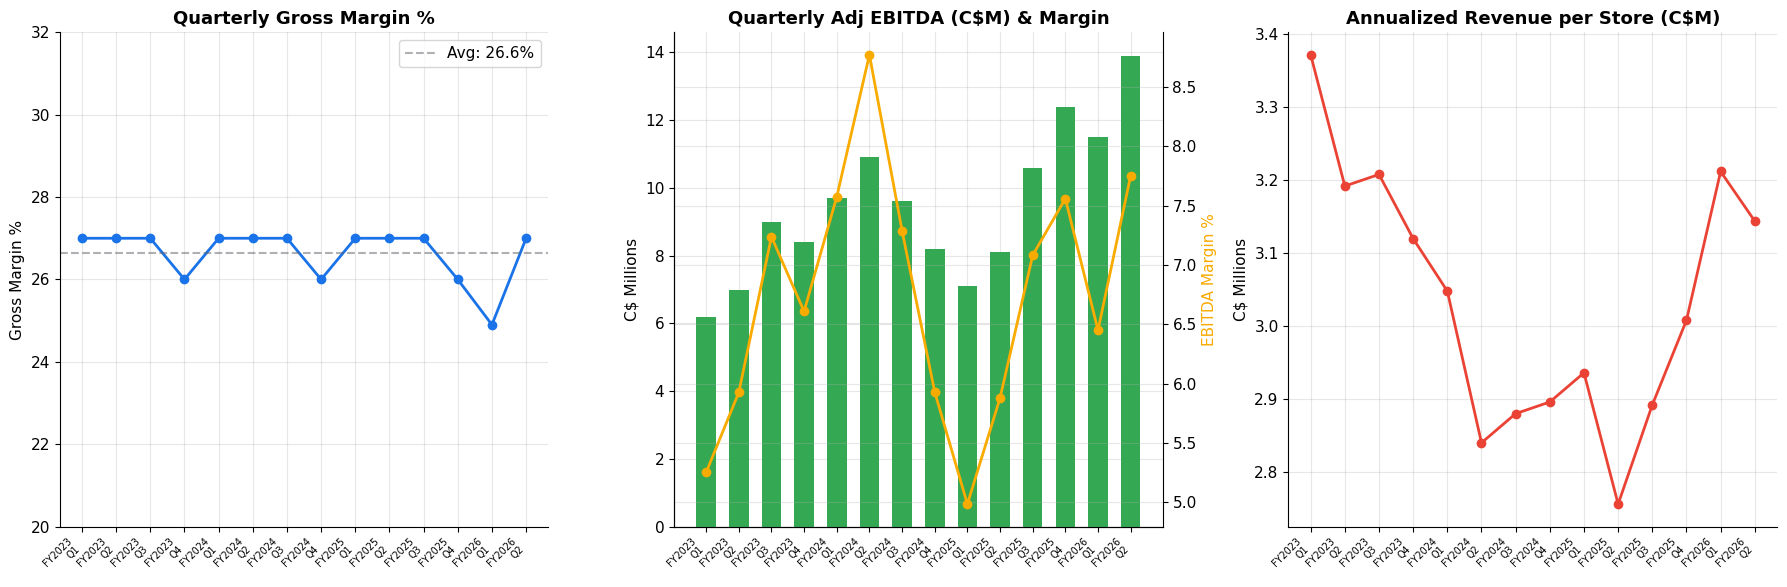


Annual Margin Summary:


,Gross Margin %,Adj EBITDA Margin %,OpEx / Rev %,SBC / Rev %,D&A / Rev %
FY,,,,,
2023,26.9,6.3,34.5,1.0,6.7
2024,27.3,7.3,25.3,0.6,4.9
2025,25.8,6.4,27.4,0.7,4.1


In [9]:
# ── Quarterly Margin & Operating Leverage Analysis ──────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

q_labels = [f"FY{fy}\n{q}" for fy, q in quarterly_kpi.index]

# --- 1. Gross Margin Trend ---
ax = axes[0]
gm = quarterly_kpi['Gross_Margin_pct']
ax.plot(range(len(gm)), gm, 'o-', color=COLORS['primary'], linewidth=2, markersize=6)
ax.axhline(y=gm.mean(), color=COLORS['neutral'], linestyle='--', alpha=0.5,
           label=f'Avg: {gm.mean():.1f}%')
ax.set_xticks(range(len(gm)))
ax.set_xticklabels(q_labels, rotation=45, fontsize=7, ha='right')
ax.set_title('Quarterly Gross Margin %', fontsize=13, fontweight='bold')
ax.set_ylabel('Gross Margin %')
ax.set_ylim(20, 32)
ax.legend()

# --- 2. Adj EBITDA & Margin ---
ax = axes[1]
ebitda = quarterly_kpi['Adj_EBITDA_K'] / 1000
ebitda_margin = quarterly_kpi['Adj_EBITDA_K'] / quarterly_kpi['Revenue_K'] * 100
ax.bar(range(len(ebitda)), ebitda, color=COLORS['secondary'], width=0.6, zorder=3,
       label='Adj EBITDA (C$M)')
ax.set_xticks(range(len(ebitda)))
ax.set_xticklabels(q_labels, rotation=45, fontsize=7, ha='right')
ax.set_title('Quarterly Adj EBITDA (C$M) & Margin', fontsize=13, fontweight='bold')
ax.set_ylabel('C$ Millions')
ax2 = ax.twinx()
ax2.plot(range(len(ebitda_margin)), ebitda_margin, 'o-', color=COLORS['gold'],
         linewidth=2, markersize=6, label='EBITDA Margin %')
ax2.set_ylabel('EBITDA Margin %', color=COLORS['gold'])
ax2.spines['right'].set_visible(True)
ax2.spines['top'].set_visible(False)

# --- 3. Revenue per Store ---
ax = axes[2]
rps = quarterly_kpi['Rev_Per_Store_Annualized_K'] / 1000
ax.plot(range(len(rps)), rps, 'o-', color=COLORS['accent'], linewidth=2, markersize=6)
ax.set_xticks(range(len(rps)))
ax.set_xticklabels(q_labels, rotation=45, fontsize=7, ha='right')
ax.set_title('Annualized Revenue per Store (C$M)', fontsize=13, fontweight='bold')
ax.set_ylabel('C$ Millions')

plt.tight_layout()
plt.show()

# Annual margin summary
print('\nAnnual Margin Summary:')
margin_summary = pd.DataFrame({
    'Gross Margin %': (income_stmt['Gross_Profit'] / income_stmt['Revenue'] * 100).round(1),
    'Adj EBITDA Margin %': (income_stmt['Adj_EBITDA'] / income_stmt['Revenue'] * 100).round(1),
    'OpEx / Rev %': (income_stmt['Total_OpEx'] / income_stmt['Revenue'] * 100).round(1),
    'SBC / Rev %': (income_stmt['SBC'] / income_stmt['Revenue'] * 100).round(1),
    'D&A / Rev %': (income_stmt['DA'] / income_stmt['Revenue'] * 100).round(1),
})
display(margin_summary)

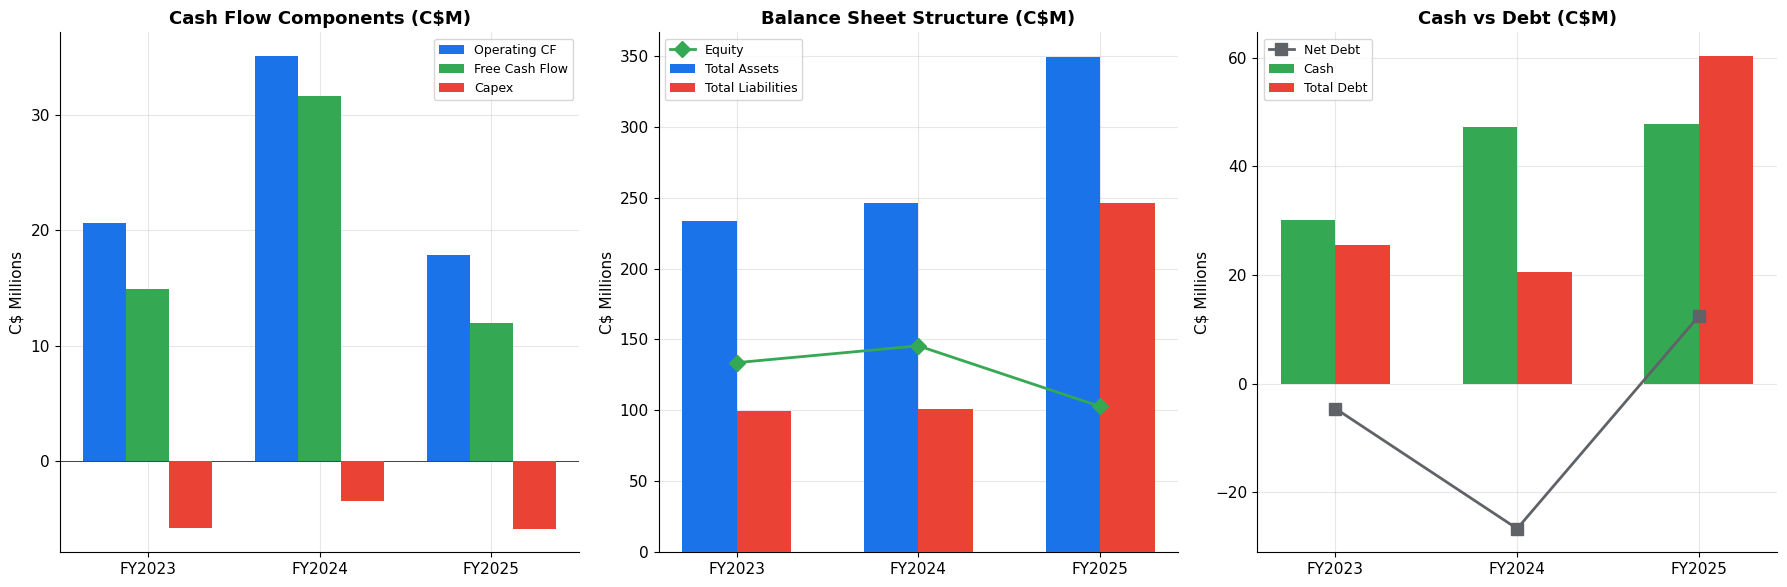


Key Balance Sheet Ratios:


,Current Ratio,Debt/Equity,Net Debt (C$M)
FY,,,
2023,1.18,0.19,-4.6
2024,1.40,0.14,-26.7
2025,1.37,0.59,12.4


In [10]:
# ── Cash Flow & Balance Sheet Analysis ──────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- 1. Cash Flow Components ---
ax = axes[0]
years = cash_flow.index
width = 0.25
x = np.arange(len(years))
ax.bar(x - width, cash_flow['Operating_CF']/1000, width, color=COLORS['primary'],
       label='Operating CF', zorder=3)
ax.bar(x, cash_flow['Free_Cash_Flow']/1000, width, color=COLORS['secondary'],
       label='Free Cash Flow', zorder=3)
ax.bar(x + width, cash_flow['Capex']/1000, width, color=COLORS['accent'],
       label='Capex', zorder=3)
ax.set_xticks(x)
ax.set_xticklabels([f'FY{y}' for y in years])
ax.set_title('Cash Flow Components (C$M)', fontsize=13, fontweight='bold')
ax.set_ylabel('C$ Millions')
ax.legend(fontsize=9)
ax.axhline(y=0, color='black', linewidth=0.5)

# --- 2. Balance Sheet Structure ---
ax = axes[1]
bs_years = balance_sheet.index
x = np.arange(len(bs_years))
ax.bar(x - 0.15, balance_sheet['Total_Assets']/1000, 0.3,
       color=COLORS['primary'], label='Total Assets', zorder=3)
ax.bar(x + 0.15, balance_sheet['Total_Liabilities']/1000, 0.3,
       color=COLORS['accent'], label='Total Liabilities', zorder=3)
ax.plot(x, balance_sheet['Shareholders_Equity']/1000, 'D-',
        color=COLORS['secondary'], linewidth=2, markersize=8,
        label='Equity', zorder=4)
ax.set_xticks(x)
ax.set_xticklabels([f'FY{y}' for y in bs_years])
ax.set_title('Balance Sheet Structure (C$M)', fontsize=13, fontweight='bold')
ax.set_ylabel('C$ Millions')
ax.legend(fontsize=9)

# --- 3. Cash & Debt ---
ax = axes[2]
cash = balance_sheet['Cash'] / 1000
total_debt = (balance_sheet['Current_Debt'] + balance_sheet['LT_Debt']) / 1000
net_debt = total_debt - cash
ax.bar(x - 0.15, cash, 0.3, color=COLORS['secondary'], label='Cash', zorder=3)
ax.bar(x + 0.15, total_debt, 0.3, color=COLORS['accent'], label='Total Debt', zorder=3)
ax.plot(x, net_debt, 's-', color=COLORS['neutral'], linewidth=2,
        markersize=8, label='Net Debt', zorder=4)
ax.set_xticks(x)
ax.set_xticklabels([f'FY{y}' for y in bs_years])
ax.set_title('Cash vs Debt (C$M)', fontsize=13, fontweight='bold')
ax.set_ylabel('C$ Millions')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Key balance sheet ratios
print('\nKey Balance Sheet Ratios:')
ratios = pd.DataFrame({
    'Current Ratio': (balance_sheet['Total_Current_Assets'] /
                      balance_sheet['Total_Current_Liab']).round(2),
    'Debt/Equity': ((balance_sheet['Current_Debt'] + balance_sheet['LT_Debt']) /
                    balance_sheet['Shareholders_Equity']).round(2),
    'Net Debt (C$M)': ((balance_sheet['Current_Debt'] + balance_sheet['LT_Debt'] -
                        balance_sheet['Cash']) / 1000).round(1),
})
display(ratios)

# Cell Group 3: Bottom-Up Operating Model (FY2026-FY2030)

The key driver is **store-count growth** combined with **same-store sales** momentum.
Revenue = (Existing stores x SSSG) + (New stores x ramp-up revenue) + Data/Advertising + Germany.

Margins expand via: operating leverage on fixed costs, Cabanalytics scaling, white-label mix shift.

In [11]:
# ============================================================
# CELL GROUP 3: BOTTOM-UP OPERATING MODEL — Assumptions
# ============================================================

proj_years = [2026, 2027, 2028, 2029, 2030]

# ── Base metrics from FY2025 ────────────────────────────────
BASE_STORES_2025 = 218
BASE_REV_PER_STORE_K = 2_700  # C$K annualized (~C$2.7M/store)
BASE_RETAIL_REV_K = 548_000   # total retail (3rd-party + white-label)
BASE_ECOMM_REV_K = 14_000
BASE_DATA_REV_K = 13_100      # Cabanalytics/Ads (excl. ELITE fees)
BASE_GERMANY_REV_K = 5_000    # partial year
BASE_OTHER_REV_K = 27_700
BASE_ELITE_MEMBERS_K = 178    # thousands (Q2 FY2026 actual)
BASE_ELITE_FEE = 33           # C$/year per member

# ── Sub-Segment Gross Margins (fixed across scenarios) ──────
GM_RETAIL_3P = 25.2       # 3rd-party retail products
GM_WHITE_LABEL = 31.5     # proprietary white-label brands
GM_ELITE = 85.0           # ELITE membership fees (~pure margin)
GM_CABANALYTICS = 65.0    # data/advertising platform
GM_ECOMM = 32.1           # e-commerce (accessories + CBD)
GM_OTHER = 0.0            # other income

# ── Scenario Assumptions ────────────────────────────────────

scenarios = {
    'Bull': {
        'new_stores':       {2026: 20, 2027: 28, 2028: 30, 2029: 28, 2030: 25},
        'sssg_pct':         {2026: 1.0, 2027: 1.5, 2028: 2.0, 2029: 1.5, 2030: 1.5},
        # Sub-segment drivers
        'white_label_pct':  {2026: 3.0, 2027: 4.5, 2028: 6.0, 2029: 8.0, 2030: 10.0},
        'elite_members_K':  {2026: 215, 2027: 330, 2028: 450, 2029: 570, 2030: 700},
        'cabanalytics_rev_K': {2026: 17_400, 2027: 20_200, 2028: 23_400, 2029: 27_200, 2030: 31_500},
        'ecomm_rev_K':      {2026: 15_000, 2027: 17_000, 2028: 19_000, 2029: 21_000, 2030: 23_000},
        'other_rev_K':      {2026: 28_000, 2027: 28_000, 2028: 28_000, 2029: 28_000, 2030: 28_000},
        # Germany (Remexian beat: Q2 FY26 rev C$31.6M @ 27% GM)
        'germany_rev_K':    {2026: 135_000, 2027: 165_000, 2028: 190_000, 2029: 210_000, 2030: 225_000},
        'germany_gm_pct':   {2026: 25.0, 2027: 26.0, 2028: 26.0, 2029: 26.0, 2030: 26.0},
        'germany_ebitda_margin_pct': {2026: 9.0, 2027: 11.0, 2028: 12.0, 2029: 12.0, 2030: 12.0},
        # Corporate cost structure (H1 FY26 opex ran ~18.9% of rev)
        'opex_pct_rev':     {2026: 18.5, 2027: 18.2, 2028: 17.8, 2029: 17.5, 2030: 17.0},
        'sbc_pct_rev':      {2026: 0.6, 2027: 0.6, 2028: 0.5, 2029: 0.5, 2030: 0.5},
        'da_pct_rev':       {2026: 4.5, 2027: 4.2, 2028: 3.9, 2029: 3.7, 2030: 3.5},
        'capex_pct_rev':    {2026: 1.2, 2027: 1.1, 2028: 1.1, 2029: 1.0, 2030: 1.0},
        'lease_pmt_pct_rev':{2026: 2.0, 2027: 2.0, 2028: 2.0, 2029: 1.9, 2030: 1.8},
        'share_dilution':   {2026: 0.02, 2027: 0.02, 2028: 0.015, 2029: 0.015, 2030: 0.01},
        'finance_exp_pct':  {2026: 1.9, 2027: 1.7, 2028: 1.5, 2029: 1.3, 2030: 1.2},
    },
    'Base': {
        'new_stores':       {2026: 18, 2027: 25, 2028: 27, 2029: 27, 2030: 26},
        'sssg_pct':         {2026: 0.0, 2027: 0.5, 2028: 1.0, 2029: 1.0, 2030: 1.0},
        'white_label_pct':  {2026: 2.0, 2027: 3.0, 2028: 4.0, 2029: 5.0, 2030: 6.0},
        'elite_members_K':  {2026: 205, 2027: 280, 2028: 350, 2029: 420, 2030: 490},
        'cabanalytics_rev_K': {2026: 16_650, 2027: 18_480, 2028: 20_510, 2029: 22_770, 2030: 25_270},
        'ecomm_rev_K':      {2026: 14_000, 2027: 14_000, 2028: 14_000, 2029: 14_000, 2030: 14_000},
        'other_rev_K':      {2026: 28_000, 2027: 28_000, 2028: 28_000, 2029: 28_000, 2030: 28_000},
        'germany_rev_K':    {2026: 130_000, 2027: 155_000, 2028: 175_000, 2029: 190_000, 2030: 200_000},
        'germany_gm_pct':   {2026: 24.0, 2027: 25.0, 2028: 25.0, 2029: 25.0, 2030: 25.0},
        'germany_ebitda_margin_pct': {2026: 9.0, 2027: 10.0, 2028: 11.0, 2029: 11.0, 2030: 11.0},
        'opex_pct_rev':     {2026: 18.5, 2027: 18.3, 2028: 18.0, 2029: 17.8, 2030: 17.5},
        'sbc_pct_rev':      {2026: 0.6, 2027: 0.6, 2028: 0.5, 2029: 0.5, 2030: 0.5},
        'da_pct_rev':       {2026: 4.5, 2027: 4.2, 2028: 3.9, 2029: 3.7, 2030: 3.5},
        'capex_pct_rev':    {2026: 1.2, 2027: 1.1, 2028: 1.1, 2029: 1.0, 2030: 1.0},
        'lease_pmt_pct_rev':{2026: 2.0, 2027: 2.0, 2028: 2.0, 2029: 1.9, 2030: 1.9},
        'share_dilution':   {2026: 0.03, 2027: 0.02, 2028: 0.02, 2029: 0.015, 2030: 0.015},
        'finance_exp_pct':  {2026: 1.9, 2027: 1.7, 2028: 1.5, 2029: 1.3, 2030: 1.2},
    },
    'Bear': {
        'new_stores':       {2026: 16, 2027: 20, 2028: 22, 2029: 20, 2030: 20},
        'sssg_pct':         {2026: -1.5, 2027: -1.0, 2028: -0.5, 2029: -0.5, 2030: -1.0},
        'white_label_pct':  {2026: 1.8, 2027: 2.0, 2028: 2.2, 2029: 2.5, 2030: 3.0},
        'elite_members_K':  {2026: 185, 2027: 210, 2028: 240, 2029: 270, 2030: 300},
        'cabanalytics_rev_K': {2026: 15_750, 2027: 16_540, 2028: 17_370, 2029: 18_240, 2030: 19_150},
        'ecomm_rev_K':      {2026: 12_000, 2027: 10_500, 2028: 9_500, 2029: 9_000, 2030: 8_500},
        'other_rev_K':      {2026: 28_000, 2027: 28_000, 2028: 28_000, 2029: 28_000, 2030: 28_000},
        'germany_rev_K':    {2026: 120_000, 2027: 130_000, 2028: 140_000, 2029: 145_000, 2030: 150_000},
        'germany_gm_pct':   {2026: 22.0, 2027: 22.0, 2028: 22.0, 2029: 22.0, 2030: 22.0},
        'germany_ebitda_margin_pct': {2026: 7.0, 2027: 8.0, 2028: 8.0, 2029: 8.0, 2030: 8.0},
        'opex_pct_rev':     {2026: 19.0, 2027: 18.8, 2028: 18.5, 2029: 18.3, 2030: 18.0},
        'sbc_pct_rev':      {2026: 0.7, 2027: 0.7, 2028: 0.6, 2029: 0.6, 2030: 0.6},
        'da_pct_rev':       {2026: 4.5, 2027: 4.3, 2028: 4.1, 2029: 4.0, 2030: 3.8},
        'capex_pct_rev':    {2026: 1.0, 2027: 0.9, 2028: 0.9, 2029: 0.8, 2030: 0.8},
        'lease_pmt_pct_rev':{2026: 2.0, 2027: 2.0, 2028: 2.0, 2029: 2.0, 2030: 2.0},
        'share_dilution':   {2026: 0.03, 2027: 0.03, 2028: 0.02, 2029: 0.02, 2030: 0.02},
        'finance_exp_pct':  {2026: 1.9, 2027: 1.7, 2028: 1.5, 2029: 1.3, 2030: 1.2},
    },
}

# Display assumptions
print('Sub-Segment Margin Assumptions (Fixed)')
print('='*60)
print(f'  3rd-Party Retail GM:  {GM_RETAIL_3P}%')
print(f'  White-Label GM:       {GM_WHITE_LABEL}%')
print(f'  ELITE Membership GM:  {GM_ELITE}%')
print(f'  Cabanalytics/Ads GM:  {GM_CABANALYTICS}%')
print(f'  E-Commerce GM:        {GM_ECOMM}%')
print(f'  Other Income GM:      {GM_OTHER}%')

print('\nScenario Assumptions Summary')
print('='*60)
for name, s in scenarios.items():
    print(f'\n--- {name} Case ---')
    print(f"  New stores/yr:         {list(s['new_stores'].values())}")
    print(f"  SSSG %:                {list(s['sssg_pct'].values())}")
    print(f"  White-Label % retail:  {list(s['white_label_pct'].values())}")
    print(f"  ELITE members (K):     {list(s['elite_members_K'].values())}")
    print(f"  Cabanalytics Rev (C$K):{list(s['cabanalytics_rev_K'].values())}")
    print(f"  E-Comm Rev (C$K):      {list(s['ecomm_rev_K'].values())}")
    print(f"  Germany Rev (C$K):     {list(s['germany_rev_K'].values())}")
    print(f"  Germany GM %:          {list(s['germany_gm_pct'].values())}")


Sub-Segment Margin Assumptions (Fixed)
  3rd-Party Retail GM:  25.2%
  White-Label GM:       31.5%
  ELITE Membership GM:  85.0%
  Cabanalytics/Ads GM:  65.0%
  E-Commerce GM:        32.1%
  Other Income GM:      0.0%

Scenario Assumptions Summary

--- Bull Case ---
  New stores/yr:         [20, 28, 30, 28, 25]
  SSSG %:                [1.0, 1.5, 2.0, 1.5, 1.5]
  White-Label % retail:  [3.0, 4.5, 6.0, 8.0, 10.0]
  ELITE members (K):     [215, 330, 450, 570, 700]
  Cabanalytics Rev (C$K):[17400, 20200, 23400, 27200, 31500]
  E-Comm Rev (C$K):      [15000, 17000, 19000, 21000, 23000]
  Germany Rev (C$K):     [135000, 165000, 190000, 210000, 225000]
  Germany GM %:          [25.0, 26.0, 26.0, 26.0, 26.0]

--- Base Case ---
  New stores/yr:         [18, 25, 27, 27, 26]
  SSSG %:                [0.0, 0.5, 1.0, 1.0, 1.0]
  White-Label % retail:  [2.0, 3.0, 4.0, 5.0, 6.0]
  ELITE members (K):     [205, 280, 350, 420, 490]
  Cabanalytics Rev (C$K):[16650, 18480, 20510, 22770, 25270]
  E-Comm R

In [12]:
# ── Build Bottom-Up Projections for All Scenarios ───────────

projections = {}

for name, s in scenarios.items():
    rows = []
    prev_stores = BASE_STORES_2025
    prev_retail_rev = BASE_RETAIL_REV_K  # total retail FY2025
    prev_shares = 87_840  # current shares outstanding (K)

    for yr in proj_years:
        # ── Store count ──
        new_stores = s['new_stores'][yr]
        total_stores = prev_stores + new_stores

        # ── Total retail revenue (3rd-party + white-label) ──
        existing_rev = prev_retail_rev * (1 + s['sssg_pct'][yr] / 100)
        new_store_rev = new_stores * BASE_REV_PER_STORE_K * 0.60  # ramp
        total_retail_rev = existing_rev + new_store_rev

        # ── Sub-segment revenue decomposition ──
        wl_pct = s['white_label_pct'][yr] / 100
        white_label_rev = total_retail_rev * wl_pct
        retail_3p_rev = total_retail_rev * (1 - wl_pct)

        elite_rev = s['elite_members_K'][yr] * BASE_ELITE_FEE  # C$K
        cabanalytics_rev = s['cabanalytics_rev_K'][yr]
        ecomm_rev = s['ecomm_rev_K'][yr]
        other_rev = s['other_rev_K'][yr]
        germany_rev = s['germany_rev_K'][yr]

        total_rev = (retail_3p_rev + white_label_rev + elite_rev +
                     cabanalytics_rev + ecomm_rev + other_rev + germany_rev)

        # ── Bottom-up gross profit ──
        gp_retail_3p = retail_3p_rev * GM_RETAIL_3P / 100
        gp_white_label = white_label_rev * GM_WHITE_LABEL / 100
        gp_elite = elite_rev * GM_ELITE / 100
        gp_cabanalytics = cabanalytics_rev * GM_CABANALYTICS / 100
        gp_ecomm = ecomm_rev * GM_ECOMM / 100
        gp_other = other_rev * GM_OTHER / 100
        gp_germany = germany_rev * s['germany_gm_pct'][yr] / 100

        gross_profit = (gp_retail_3p + gp_white_label + gp_elite +
                        gp_cabanalytics + gp_ecomm + gp_other + gp_germany)
        gross_margin = gross_profit / total_rev * 100

        # ── EBITDA (top-down from total revenue) ──
        opex = total_rev * s['opex_pct_rev'][yr] / 100
        adj_ebitda = gross_profit - opex
        ebitda_margin = adj_ebitda / total_rev * 100

        da = total_rev * s['da_pct_rev'][yr] / 100
        sbc = total_rev * s['sbc_pct_rev'][yr] / 100

        # ── NCI: 49% of Germany EBITDA ──
        germany_ebitda = germany_rev * s['germany_ebitda_margin_pct'][yr] / 100
        nci_charge = 0.49 * germany_ebitda

        # ── Cash flow ──
        capex = total_rev * s['capex_pct_rev'][yr] / 100
        lease_pmts = total_rev * s['lease_pmt_pct_rev'][yr] / 100
        fcf = adj_ebitda - capex - lease_pmts
        fcf_equity = fcf - nci_charge

        # ── Shares ──
        shares = prev_shares * (1 + s['share_dilution'][yr])

        rows.append({
            'Year': yr,
            'Stores': total_stores,
            'New_Stores': new_stores,
            'Retail_3P_Rev_K': retail_3p_rev,
            'White_Label_Rev_K': white_label_rev,
            'ELITE_Rev_K': elite_rev,
            'Cabanalytics_Rev_K': cabanalytics_rev,
            'Ecomm_Rev_K': ecomm_rev,
            'Other_Rev_K': other_rev,
            'Germany_Rev_K': germany_rev,
            'Revenue_K': total_rev,
            'GP_Retail_3P_K': gp_retail_3p,
            'GP_White_Label_K': gp_white_label,
            'GP_ELITE_K': gp_elite,
            'GP_Cabanalytics_K': gp_cabanalytics,
            'GP_Ecomm_K': gp_ecomm,
            'GP_Other_K': gp_other,
            'GP_Germany_K': gp_germany,
            'Gross_Profit_K': gross_profit,
            'Gross_Margin_pct': gross_margin,
            'Adj_EBITDA_K': adj_ebitda,
            'EBITDA_Margin_pct': ebitda_margin,
            'DA_K': da,
            'SBC_K': sbc,
            'Germany_EBITDA_K': germany_ebitda,
            'NCI_K': nci_charge,
            'Capex_K': capex,
            'Lease_Pmts_K': lease_pmts,
            'FCF_K': fcf,
            'FCF_Equity_K': fcf_equity,
            'Shares_K': shares,
        })

        prev_stores = total_stores
        prev_retail_rev = total_retail_rev
        prev_shares = shares

    projections[name] = pd.DataFrame(rows).set_index('Year')

    # Backward-compatible columns for downstream cells
    projections[name]['Retail_Rev_K'] = projections[name]['Retail_3P_Rev_K'] + projections[name]['White_Label_Rev_K']
    projections[name]['Data_Rev_K'] = projections[name]['Cabanalytics_Rev_K']

# Display Base case projections
print('Base Case Projections (C$K)')
print('='*60)
base = projections['Base']
display(base[['Stores','Revenue_K','Gross_Profit_K','Gross_Margin_pct',
              'Adj_EBITDA_K','EBITDA_Margin_pct','NCI_K','FCF_Equity_K','Shares_K']].round(1))

# Display sub-segment GP breakdown
print('\nBase Case Sub-Segment GP Breakdown (C$K)')
print('='*60)
gp_cols = ['GP_Retail_3P_K','GP_White_Label_K','GP_ELITE_K','GP_Cabanalytics_K',
           'GP_Ecomm_K','GP_Germany_K','Gross_Profit_K','Gross_Margin_pct']
display(base[gp_cols].round(1))

# ── Remexian Buyout in FY2028 ───────────────────────────────
# HITI exercises call option for remaining 49% at 4x trailing EBITDA
# From FY2029 onward: 100% owned, NCI = 0

buyout_costs = {}
for name in projections:
    p = projections[name]
    buyout_costs[name] = 4 * p.loc[2028, 'Germany_EBITDA_K']
    p.loc[2028, 'FCF_Equity_K'] -= buyout_costs[name]
    for yr in [2029, 2030]:
        p.loc[yr, 'NCI_K'] = 0
        p.loc[yr, 'FCF_Equity_K'] = p.loc[yr, 'FCF_K']

print('\nRemexian Buyout Impact (49% acquisition at 4x EBITDA)')
print('='*60)
for name in ['Bull', 'Base', 'Bear']:
    cost = buyout_costs[name]
    print(f'  {name}: Buyout cost C${cost/1000:.1f}M (4 x C${cost/4/1000:.1f}M EBITDA)')

# ── Fade Period: 2031-2035 ──────────────────────────────────
# Phase 2 projections: simplified model converging to terminal assumptions.
# Key drivers linearly interpolate from 2030 values to terminal targets.

fade_years = [2031, 2032, 2033, 2034, 2035]

# Terminal targets (hard constraints the model converges to)
# Terminal targets vary by scenario
TERMINAL_OPEX_PCT = 17.0
TERMINAL_DA_PCT = 3.2
TERMINAL_CAPEX_PCT = 1.0
TERMINAL_LEASE_PCT = 1.8
TERMINAL_SHARE_DILUTION = 0.01

fade_params = {
    'Bull': {'stores_target': 356, 'sssg': 1.5, 'germany_rev_growth': 0.08,
             'germany_gm': 24.0, 'caba_cagr': 0.16, 'ecomm_growth': 0.05,
             'sbc_pct': 0.5,
             'terminal_wl_pct': 22.0, 'terminal_elite_K': 1250, 'terminal_germany_ebitda_K': 40_000},
    'Base': {'stores_target': 350, 'sssg': 1.0, 'germany_rev_growth': 0.05,
             'germany_gm': 22.0, 'caba_cagr': 0.11, 'ecomm_growth': 0.0,
             'sbc_pct': 0.5,
             'terminal_wl_pct': 20.0, 'terminal_elite_K': 1000, 'terminal_germany_ebitda_K': 30_000},
    'Bear': {'stores_target': 320, 'sssg': -0.5, 'germany_rev_growth': 0.03,
             'germany_gm': 20.0, 'caba_cagr': 0.05, 'ecomm_growth': -0.05,
             'sbc_pct': 0.6,
             'terminal_wl_pct': 16.0, 'terminal_elite_K': 750, 'terminal_germany_ebitda_K': 25_000},
}

fade_projections = {}

for name in ['Bull', 'Base', 'Bear']:
    fp = fade_params[name]
    p = projections[name]
    rows = []

    # Starting values from 2030
    prev_retail_rev = p.loc[2030, 'Retail_3P_Rev_K'] + p.loc[2030, 'White_Label_Rev_K']
    prev_germany_rev = p.loc[2030, 'Germany_Rev_K']
    prev_caba_rev = p.loc[2030, 'Cabanalytics_Rev_K']
    prev_ecomm_rev = p.loc[2030, 'Ecomm_Rev_K']
    prev_shares = p.loc[2030, 'Shares_K']
    wl_2030 = float(scenarios[name]['white_label_pct'][2030])
    elite_2030 = float(scenarios[name]['elite_members_K'][2030])
    stores = fp['stores_target']

    for i, yr in enumerate(fade_years):
        t = (i + 1) / 5.0  # interpolation factor 0.2 to 1.0

        # ── Interpolate drivers toward terminal ──
        wl_pct = wl_2030 + t * (fp['terminal_wl_pct'] - wl_2030)
        elite_members = elite_2030 + t * (fp['terminal_elite_K'] - elite_2030)
        opex_pct_yr = scenarios[name]['opex_pct_rev'][2030] + t * (TERMINAL_OPEX_PCT - scenarios[name]['opex_pct_rev'][2030])
        da_pct = p.loc[2030, 'DA_K'] / p.loc[2030, 'Revenue_K'] * 100
        da_pct = da_pct + t * (TERMINAL_DA_PCT - da_pct)
        capex_pct = scenarios[name]['capex_pct_rev'][2030] + t * (TERMINAL_CAPEX_PCT - scenarios[name]['capex_pct_rev'][2030])
        lease_pct = scenarios[name]['lease_pmt_pct_rev'][2030] + t * (TERMINAL_LEASE_PCT - scenarios[name]['lease_pmt_pct_rev'][2030])

        # ── Revenue ──
        total_retail_rev = prev_retail_rev * (1 + fp['sssg'] / 100)
        white_label_rev = total_retail_rev * wl_pct / 100
        retail_3p_rev = total_retail_rev * (1 - wl_pct / 100)

        elite_rev = elite_members * BASE_ELITE_FEE
        caba_rev = prev_caba_rev * (1 + fp['caba_cagr'])
        ecomm_rev = prev_ecomm_rev * (1 + fp['ecomm_growth'])
        germany_rev = prev_germany_rev * (1 + fp['germany_rev_growth'])
        other_rev = 28_000

        total_rev = retail_3p_rev + white_label_rev + elite_rev + caba_rev + ecomm_rev + other_rev + germany_rev

        # ── Bottom-up GP ──
        gp = (retail_3p_rev * GM_RETAIL_3P / 100 +
              white_label_rev * GM_WHITE_LABEL / 100 +
              elite_rev * GM_ELITE / 100 +
              caba_rev * GM_CABANALYTICS / 100 +
              ecomm_rev * GM_ECOMM / 100 +
              other_rev * GM_OTHER / 100 +
              germany_rev * fp['germany_gm'] / 100)

        # ── EBITDA ──
        opex = total_rev * opex_pct_yr / 100
        adj_ebitda = gp - opex

        # ── Germany EBITDA (for tracking convergence to C$30M) ──
        germany_ebitda_2030 = p.loc[2030, 'Germany_EBITDA_K']
        germany_ebitda = germany_ebitda_2030 + t * (fp['terminal_germany_ebitda_K'] - germany_ebitda_2030)

        # ── NCI = 0 (100% owned after 2028 buyout) ──
        nci = 0

        # ── FCF ──
        capex_yr = total_rev * (scenarios[name]['capex_pct_rev'][2030] + t * (TERMINAL_CAPEX_PCT - scenarios[name]['capex_pct_rev'][2030])) / 100
        lease_yr = total_rev * (scenarios[name]['lease_pmt_pct_rev'][2030] + t * (TERMINAL_LEASE_PCT - scenarios[name]['lease_pmt_pct_rev'][2030])) / 100
        fcf = adj_ebitda - capex_yr - lease_yr
        fcf_equity = fcf  # no NCI

        shares = prev_shares * (1 + TERMINAL_SHARE_DILUTION)

        rows.append({
            'Year': yr,
            'Revenue_K': total_rev,
            'Gross_Profit_K': gp,
            'Gross_Margin_pct': gp / total_rev * 100,
            'Adj_EBITDA_K': adj_ebitda,
            'EBITDA_Margin_pct': adj_ebitda / total_rev * 100,
            'Germany_EBITDA_K': germany_ebitda,
            'NCI_K': nci,
            'FCF_K': fcf,
            'FCF_Equity_K': fcf_equity,
            'Shares_K': shares,
            'Capex_K': capex_yr,
            'Lease_Pmts_K': lease_yr,
            'WL_Pct': wl_pct,
            'ELITE_K': elite_members,
        })

        prev_retail_rev = total_retail_rev
        prev_germany_rev = germany_rev
        prev_caba_rev = caba_rev
        prev_ecomm_rev = ecomm_rev
        prev_shares = shares

    fade_projections[name] = pd.DataFrame(rows).set_index('Year')

# Add backward-compatible columns for cells that reference them
for name in fade_projections:
    fade_projections[name]['Stores'] = fade_params[name]['stores_target']

print('\nBase Case Fade Period (2031-2035, C$K)')
print('='*60)
fade_base = fade_projections['Base']
display(fade_base[['Revenue_K','Gross_Margin_pct','Adj_EBITDA_K',
                    'EBITDA_Margin_pct','FCF_Equity_K','WL_Pct','ELITE_K','Shares_K']].round(1))


Base Case Projections (C$K)


,Stores,Revenue_K,Gross_Profit_K,Gross_Margin_pct,Adj_EBITDA_K,EBITDA_Margin_pct,NCI_K,FCF_Equity_K,Shares_K
Year,,,,,,,,,
2026,236,772575.0,198438.3,25.7,55511.9,7.2,5733.0,25056.5,90475.2
2027,261,845265.8,220660.4,26.1,65976.7,7.8,7595.0,32178.5,92284.7
2028,288,919551.3,242046.4,26.3,76527.2,8.3,9432.5,38588.6,94130.4
2029,315,989566.2,262522.4,26.5,86379.6,8.7,10241.0,47441.2,95542.4
2030,341,1053705.5,281682.5,26.7,97284.0,9.2,10780.0,55946.6,96975.5



Base Case Sub-Segment GP Breakdown (C$K)


,GP_Retail_3P_K,GP_White_Label_K,GP_ELITE_K,GP_Cabanalytics_K,GP_Ecomm_K,GP_Germany_K,Gross_Profit_K,Gross_Margin_pct
Year,,,,,,,,
2026,142535.4,3636.1,5750.2,10822.5,4494.0,31200.0,198438.3,25.7
2027,151686.2,5864.2,7854.0,12012.0,4494.0,38750.0,220660.4,26.1
2028,162205.2,8448.2,9817.5,13331.5,4494.0,43750.0,242046.4,26.3
2029,172592.1,11354.7,11781.0,14800.5,4494.0,47500.0,262522.4,26.5
2030,182460.5,14558.0,13744.5,16425.5,4494.0,50000.0,281682.5,26.7



Remexian Buyout Impact (49% acquisition at 4x EBITDA)
  Bull: Buyout cost C$91.2M (4 x C$22.8M EBITDA)
  Base: Buyout cost C$77.0M (4 x C$19.2M EBITDA)
  Bear: Buyout cost C$44.8M (4 x C$11.2M EBITDA)

Base Case Fade Period (2031-2035, C$K)


,Revenue_K,Gross_Margin_pct,Adj_EBITDA_K,EBITDA_Margin_pct,FCF_Equity_K,WL_Pct,ELITE_K,Shares_K
Year,,,,,,,,
2031,1077553.9,26.5,98398.6,9.1,67365.0,8.8,592.0,97945.2
2032,1102285.0,26.9,105764.0,9.6,74238.6,11.6,694.0,98924.7
2033,1127958.4,27.3,113400.6,10.1,81366.6,14.4,796.0,99913.9
2034,1154638.3,27.6,121331.0,10.5,88770.2,17.2,898.0,100913.1
2035,1182394.5,28.0,129580.0,11.0,96472.9,20.0,1000.0,101922.2


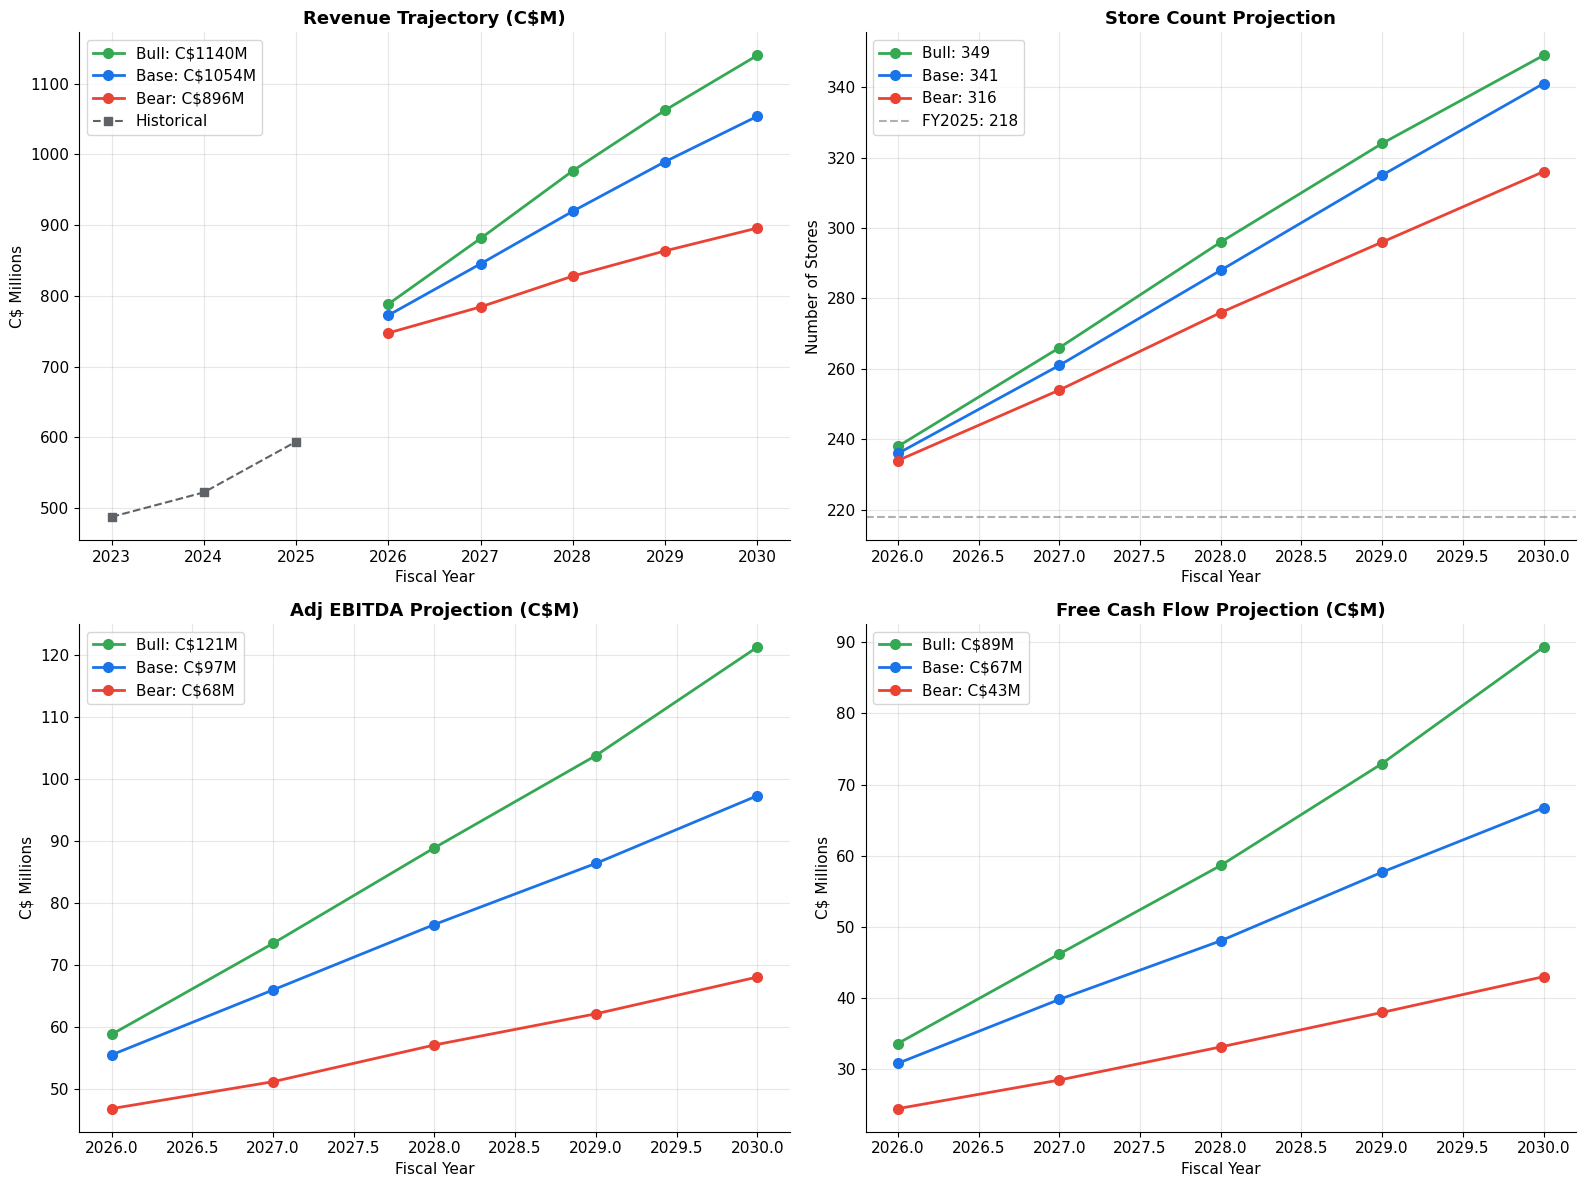

In [13]:
# ── Scenario Comparison Charts ──────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

scenario_colors = {'Bull': COLORS['secondary'], 'Base': COLORS['primary'],
                   'Bear': COLORS['accent']}

# --- 1. Revenue Trajectory ---
ax = axes[0, 0]
for name, df in projections.items():
    rev = df['Revenue_K'] / 1000
    ax.plot(proj_years, rev, 'o-', color=scenario_colors[name], linewidth=2,
            markersize=7, label=f'{name}: C${rev.iloc[-1]:.0f}M')
# Add historical
hist_rev = income_stmt['Revenue'] / 1000
ax.plot(income_stmt.index, hist_rev, 's--', color=COLORS['neutral'],
        linewidth=1.5, markersize=6, label='Historical')
ax.set_title('Revenue Trajectory (C$M)', fontsize=13, fontweight='bold')
ax.set_ylabel('C$ Millions')
ax.legend()

# --- 2. Store Count ---
ax = axes[0, 1]
for name, df in projections.items():
    ax.plot(proj_years, df['Stores'], 'o-', color=scenario_colors[name],
            linewidth=2, markersize=7, label=f'{name}: {df["Stores"].iloc[-1]:.0f}')
ax.axhline(y=218, color=COLORS['neutral'], linestyle='--', alpha=0.5, label='FY2025: 218')
ax.set_title('Store Count Projection', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Stores')
ax.legend()

# --- 3. Adj EBITDA ---
ax = axes[1, 0]
for name, df in projections.items():
    ebitda = df['Adj_EBITDA_K'] / 1000
    ax.plot(proj_years, ebitda, 'o-', color=scenario_colors[name], linewidth=2,
            markersize=7, label=f'{name}: C${ebitda.iloc[-1]:.0f}M')
ax.set_title('Adj EBITDA Projection (C$M)', fontsize=13, fontweight='bold')
ax.set_ylabel('C$ Millions')
ax.legend()

# --- 4. Free Cash Flow ---
ax = axes[1, 1]
for name, df in projections.items():
    fcf = df['FCF_K'] / 1000
    ax.plot(proj_years, fcf, 'o-', color=scenario_colors[name], linewidth=2,
            markersize=7, label=f'{name}: C${fcf.iloc[-1]:.0f}M')
ax.set_title('Free Cash Flow Projection (C$M)', fontsize=13, fontweight='bold')
ax.set_ylabel('C$ Millions')
ax.legend()

for ax in axes.flat:
    ax.set_xlabel('Fiscal Year')

plt.tight_layout()
plt.show()

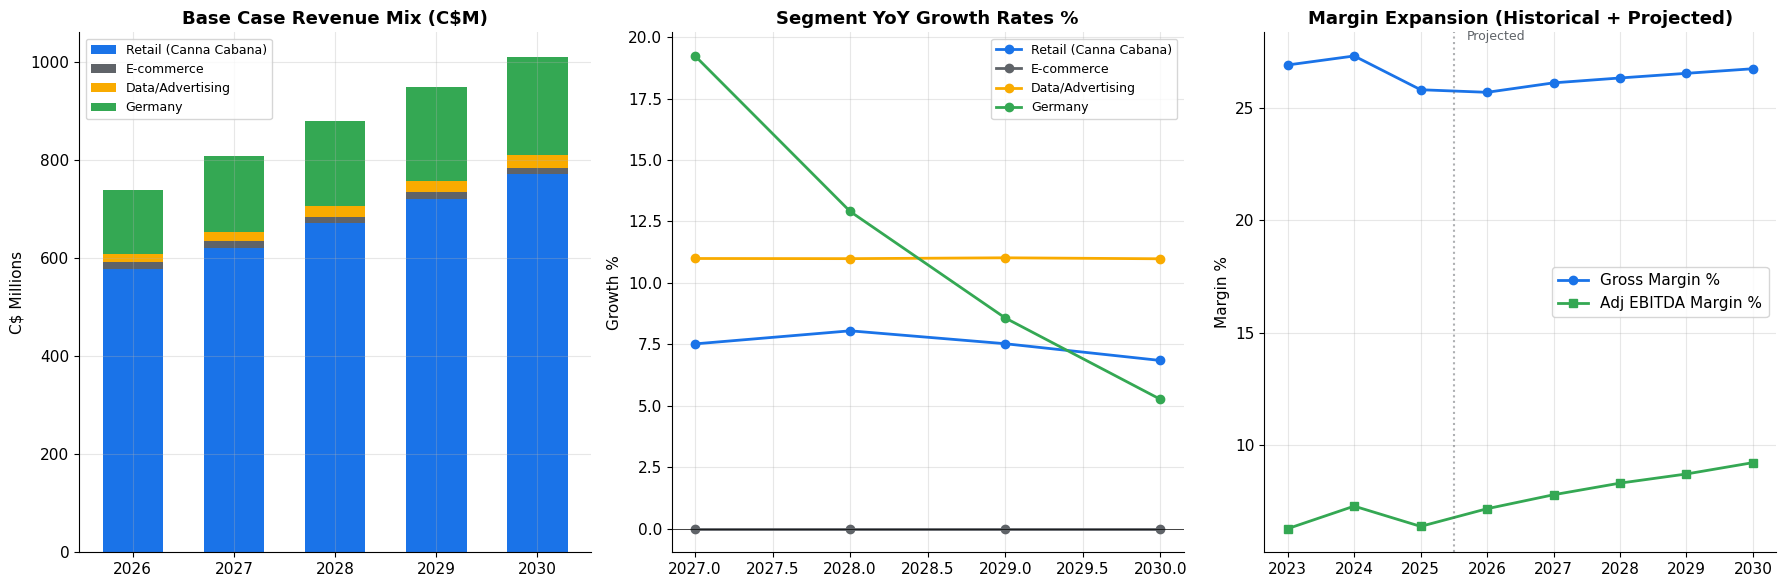


Base Case Revenue Mix (%):


,Retail (Canna Cabana),E-commerce,Data/Advertising,Germany
2026,74.7,1.8,2.2,16.8
2027,73.4,1.7,2.2,18.3
2028,72.9,1.5,2.2,19.0
2029,72.9,1.4,2.3,19.2
2030,73.1,1.3,2.4,19.0


In [14]:
# ── Segment Growth Matrix / Revenue Mix Analysis ─────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Base case segment breakdown
base = projections['Base']

# --- 1. Revenue Mix (stacked area) ---
ax = axes[0]
segments = ['Retail_Rev_K', 'Ecomm_Rev_K', 'Data_Rev_K', 'Germany_Rev_K']
seg_labels = ['Retail (Canna Cabana)', 'E-commerce', 'Data/Advertising', 'Germany']
seg_colors = [COLORS['primary'], COLORS['neutral'], COLORS['gold'], COLORS['secondary']]

# Build stacked data
bottom = np.zeros(len(proj_years))
for seg, label, color in zip(segments, seg_labels, seg_colors):
    vals = base[seg] / 1000
    ax.bar(proj_years, vals, bottom=bottom, color=color, label=label, width=0.6)
    bottom += vals.values

ax.set_title('Base Case Revenue Mix (C$M)', fontsize=13, fontweight='bold')
ax.set_ylabel('C$ Millions')
ax.legend(loc='upper left', fontsize=9)

# --- 2. Segment Growth Rates ---
ax = axes[1]
for seg, label, color in zip(segments, seg_labels, seg_colors):
    growth = base[seg].pct_change() * 100
    ax.plot(proj_years[1:], growth.dropna(), 'o-', color=color, linewidth=2,
            markersize=6, label=label)
ax.set_title('Segment YoY Growth Rates %', fontsize=13, fontweight='bold')
ax.set_ylabel('Growth %')
ax.legend(fontsize=9)
ax.axhline(y=0, color='black', linewidth=0.5)

# --- 3. Margin Expansion Bridge ---
ax = axes[2]
metrics = ['Gross_Margin_pct', 'EBITDA_Margin_pct']
metric_labels = ['Gross Margin %', 'Adj EBITDA Margin %']
metric_colors = [COLORS['primary'], COLORS['secondary']]

# Add historical points
all_years = [2023, 2024, 2025] + proj_years
gm_hist = [26.9, 27.3, 25.8]
ebitda_hist = [6.3, 7.3, 6.4]
gm_proj = list(base['Gross_Margin_pct'])
ebitda_proj = list(base['EBITDA_Margin_pct'])

ax.plot(all_years, gm_hist + gm_proj, 'o-', color=COLORS['primary'],
        linewidth=2, markersize=6, label='Gross Margin %')
ax.plot(all_years, ebitda_hist + ebitda_proj, 's-', color=COLORS['secondary'],
        linewidth=2, markersize=6, label='Adj EBITDA Margin %')
ax.axvline(x=2025.5, color=COLORS['neutral'], linestyle=':', alpha=0.5)
ax.text(2025.7, 28, 'Projected', fontsize=9, color=COLORS['neutral'])
ax.set_title('Margin Expansion (Historical + Projected)', fontsize=13, fontweight='bold')
ax.set_ylabel('Margin %')
ax.legend()

plt.tight_layout()
plt.show()

# Revenue mix table
print('\nBase Case Revenue Mix (%):')
mix = pd.DataFrame(index=proj_years)
for seg, label in zip(segments, seg_labels):
    mix[label] = (base[seg] / base['Revenue_K'] * 100).round(1)
display(mix)

# Cell Group 4: 3-Statement Projected Model (FY2026-FY2030)

Base case projected income statement, balance sheet, and cash flow statement.

In [15]:
# ============================================================
# CELL GROUP 4: 3-STATEMENT MODEL (Base Case)
# ============================================================

base = projections['Base']

# ── Projected Income Statement ──────────────────────────────
proj_is = pd.DataFrame(index=proj_years)
proj_is['Revenue'] = base['Revenue_K']
proj_is['COGS'] = base['Revenue_K'] - base['Gross_Profit_K']
proj_is['Gross_Profit'] = base['Gross_Profit_K']
proj_is['Gross_Margin_%'] = base['Gross_Margin_pct']

# OpEx breakdown (from scenario assumptions)
for yr in proj_years:
    proj_is.loc[yr, 'Total_OpEx'] = base.loc[yr, 'Revenue_K'] * scenarios['Base']['opex_pct_rev'][yr] / 100

proj_is['Operating_Income'] = proj_is['Gross_Profit'] - proj_is['Total_OpEx']

# Below the line
for yr in proj_years:
    proj_is.loc[yr, 'Finance_Expense'] = -base.loc[yr, 'Revenue_K'] * scenarios['Base']['finance_exp_pct'][yr] / 100
    proj_is.loc[yr, 'Other_Items'] = 0  # assume no more large derivative losses
    proj_is.loc[yr, 'Pretax_Income'] = (proj_is.loc[yr, 'Operating_Income'] +
                                         proj_is.loc[yr, 'Finance_Expense'])
    # Tax: minimal due to NOL carryforwards
    if proj_is.loc[yr, 'Pretax_Income'] > 0:
        proj_is.loc[yr, 'Tax'] = -proj_is.loc[yr, 'Pretax_Income'] * 0.10  # sheltered
    else:
        proj_is.loc[yr, 'Tax'] = 0
    proj_is.loc[yr, 'Net_Income'] = proj_is.loc[yr, 'Pretax_Income'] + proj_is.loc[yr, 'Tax']

    # NCI deduction (49% of Germany EBITDA, already computed in projections)
    proj_is.loc[yr, 'NCI'] = -base.loc[yr, 'NCI_K']
    proj_is.loc[yr, 'Net_Income_to_HITI'] = proj_is.loc[yr, 'Net_Income'] + proj_is.loc[yr, 'NCI']

proj_is['DA'] = base['DA_K']
proj_is['SBC'] = base['SBC_K']
proj_is['Adj_EBITDA'] = base['Adj_EBITDA_K']

print('Projected Income Statement — Base Case (C$K)')
print('='*60)
display(proj_is[['Revenue','Gross_Profit','Gross_Margin_%','Total_OpEx',
                 'Operating_Income','Finance_Expense','Pretax_Income',
                 'Tax','Net_Income','NCI','Net_Income_to_HITI','Adj_EBITDA']].round(0).T)

Projected Income Statement — Base Case (C$K)


,2026,2027,2028,2029,2030
Revenue,772575.0,845266.0,919551.0,989566.0,1053706.0
Gross_Profit,198438.0,220660.0,242046.0,262522.0,281683.0
Gross_Margin_%,26.0,26.0,26.0,27.0,27.0
Total_OpEx,142926.0,154684.0,165519.0,176143.0,184398.0
Operating_Income,55512.0,65977.0,76527.0,86380.0,97284.0
Finance_Expense,-14679.0,-14370.0,-13793.0,-12864.0,-12644.0
Pretax_Income,40833.0,51607.0,62734.0,73515.0,84640.0
Tax,-4083.0,-5161.0,-6273.0,-7352.0,-8464.0
Net_Income,36750.0,46446.0,56461.0,66164.0,76176.0
NCI,-5733.0,-7595.0,-9432.0,-0.0,-0.0


In [16]:
# ── Balance Sheet & Cash Flow — Base Case ───────────────────

# ── Projected Cash Flow Statement ───────────────────────────
proj_cf = pd.DataFrame(index=proj_years)
proj_cf['Net_Income'] = proj_is['Net_Income_to_HITI']  # NCI-adjusted net income
proj_cf['DA'] = proj_is['DA']
proj_cf['SBC'] = proj_is['SBC']
proj_cf['WC_Changes'] = [500, 500, 500, 500, 500]  # minimal WC investment
proj_cf['Operating_CF'] = (proj_cf['Net_Income'] + proj_cf['DA'] +
                            proj_cf['SBC'] + proj_cf['WC_Changes'])
proj_cf['Capex'] = -base['Capex_K']
proj_cf['Free_Cash_Flow'] = proj_cf['Operating_CF'] + proj_cf['Capex']
proj_cf['Lease_Payments'] = -base['Lease_Pmts_K']
proj_cf['Debt_Net'] = [0, 0, -5_000, -5_000, -5_000]  # gradual deleveraging
proj_cf['FCF_After_Leases'] = base['FCF_Equity_K']  # NCI-adjusted FCF

# ── Projected Balance Sheet ─────────────────────────────────
proj_bs = pd.DataFrame(index=proj_years)
prev_cash = 47_880
prev_debt = 60_320  # current + LT debt at FY2025
prev_equity = 102_790

for yr in proj_years:
    cash_gen = proj_cf.loc[yr, 'FCF_After_Leases']
    debt_chg = proj_cf.loc[yr, 'Debt_Net']

    proj_bs.loc[yr, 'Cash'] = prev_cash + cash_gen + debt_chg
    proj_bs.loc[yr, 'Total_Debt'] = max(0, prev_debt + debt_chg)
    proj_bs.loc[yr, 'Net_Debt'] = proj_bs.loc[yr, 'Total_Debt'] - proj_bs.loc[yr, 'Cash']
    proj_bs.loc[yr, 'Equity'] = prev_equity + proj_is.loc[yr, 'Net_Income_to_HITI'] + proj_is.loc[yr, 'SBC']

    prev_cash = proj_bs.loc[yr, 'Cash']
    prev_debt = proj_bs.loc[yr, 'Total_Debt']
    prev_equity = proj_bs.loc[yr, 'Equity']

print('Projected Cash Flow Statement — Base Case (C$K)')
print('='*60)
display(proj_cf.round(0).T)

print('\nProjected Balance Sheet — Base Case (C$K)')
print('='*60)
display(proj_bs.round(0).T)

# Verification: does cash balance stay positive?
print('\n--- Verification ---')
print(f'Cash balance remains positive: {all(proj_bs["Cash"] > 0)}')
print(f'Min cash balance: C${proj_bs["Cash"].min()/1000:.1f}M')
print(f'Equity grows: {proj_bs["Equity"].iloc[-1] > proj_bs["Equity"].iloc[0]}')

Projected Cash Flow Statement — Base Case (C$K)


,2026,2027,2028,2029,2030
Net_Income,31017.0,38851.0,47028.0,66164.0,76176.0
DA,34766.0,35501.0,35862.0,36614.0,36880.0
SBC,4635.0,5072.0,4598.0,4948.0,5269.0
WC_Changes,500.0,500.0,500.0,500.0,500.0
Operating_CF,70918.0,79924.0,87988.0,108225.0,118824.0
Capex,-9271.0,-9298.0,-10115.0,-9896.0,-10537.0
Free_Cash_Flow,61647.0,70626.0,77873.0,98330.0,108287.0
Lease_Payments,-15452.0,-16905.0,-18391.0,-18802.0,-20020.0
Debt_Net,0.0,0.0,-5000.0,-5000.0,-5000.0
FCF_After_Leases,25057.0,32178.0,-38411.0,57682.0,66727.0



Projected Balance Sheet — Base Case (C$K)


,2026,2027,2028,2029,2030
Cash,72937.0,105115.0,61704.0,114386.0,176112.0
Total_Debt,60320.0,60320.0,55320.0,50320.0,45320.0
Net_Debt,-12617.0,-44795.0,-6384.0,-64066.0,-130792.0
Equity,138442.0,182365.0,233991.0,305103.0,386547.0



--- Verification ---
Cash balance remains positive: True
Min cash balance: C$61.7M
Equity grows: True


# Cell Group 5: DCF Valuation

In [17]:
# ============================================================
# CELL GROUP 5: DCF VALUATION
# ============================================================

def run_dcf(proj_df, fade_df, scenario_name='Base',
            risk_free=0.043, beta=1.01, erp=0.055, cannabis_premium=0.02,
            terminal_growth=0.025, net_debt_K=42_000):
    """
    DCF valuation for High Tide Inc. (10-Year Model)
    Phase 1 (2026-2030): detailed bottom-up projections
    Phase 2 (2031-2035): fade period converging to terminal assumptions
    Uses FCF to Equity = Adj EBITDA - Capex - Lease Payments - NCI (no cash taxes due to NOLs)
    """
    cost_of_equity = risk_free + beta * erp
    wacc = cost_of_equity + cannabis_premium

    print(f'{"="*58}')
    print(f'  DCF VALUATION - {scenario_name.upper()} CASE (10-YEAR)')
    print(f'{"="*58}')
    print(f'\n  WACC Calculation:')
    print(f'    Risk-free rate:      {risk_free:.1%}')
    print(f'    Beta:                {beta:.2f}')
    print(f'    Equity risk premium: {erp:.1%}')
    print(f'    Cost of equity:      {cost_of_equity:.1%}')
    print(f'    Cannabis premium:    {cannabis_premium:.1%}')
    print(f'    WACC:                {wacc:.1%}')
    print(f'    Terminal growth:     {terminal_growth:.1%}')

    all_years = list(proj_df.index) + list(fade_df.index)

    fcf_values = []
    print(f'\n  {"Year":>6} {"EBITDA":>10} {"Capex":>8} {"Lease":>8} {"NCI":>8} {"FCF Eq":>10} {"Phase":>8}')
    print(f'  {"-"*62}')

    for yr in all_years:
        if yr in proj_df.index:
            df = proj_df
            phase = 'Detail'
        else:
            df = fade_df
            phase = 'Fade'
        ebitda = df.loc[yr, 'Adj_EBITDA_K']
        capex = df.loc[yr, 'Capex_K']
        lease = df.loc[yr, 'Lease_Pmts_K']
        nci = df.loc[yr, 'NCI_K']
        fcf_eq = df.loc[yr, 'FCF_Equity_K']
        fcf_values.append(fcf_eq)
        print(f'  {yr:>6} {ebitda:>10,.0f} {-capex:>8,.0f} {-lease:>8,.0f} {-nci:>8,.0f} {fcf_eq:>10,.0f} {phase:>8}')

    # Discount FCFs
    pv_fcfs = [fcf / (1 + wacc) ** (i + 1) for i, fcf in enumerate(fcf_values)]
    pv_fcf_total = sum(pv_fcfs)

    # Terminal value (Gordon Growth) at year 10
    terminal_fcf = fcf_values[-1] * (1 + terminal_growth)
    terminal_value = terminal_fcf / (wacc - terminal_growth)
    pv_terminal = terminal_value / ((1 + wacc) ** len(all_years))

    ev = pv_fcf_total + pv_terminal
    equity_value = ev - net_debt_K

    diluted_shares = fade_df['Shares_K'].iloc[-1]
    implied_price = equity_value / diluted_shares

    print(f'\n  Enterprise Value Bridge (C$K):')
    print(f'    PV of FCFs (2026-2035):  {pv_fcf_total:>12,.0f}')
    print(f'    PV of Terminal Value:     {pv_terminal:>12,.0f}')
    print(f'    Enterprise Value:        {ev:>12,.0f}')
    print(f'    - Net Debt:              {-net_debt_K:>12,.0f}')
    print(f'    Equity Value:            {equity_value:>12,.0f}')
    print(f'    Diluted Shares (K):      {diluted_shares:>12,.0f}')
    print(f'    Implied Price:           C${implied_price:>10.2f}')
    print(f'    TV as % of EV:           {pv_terminal/ev*100:.1f}%')

    return {
        'scenario': scenario_name,
        'wacc': wacc,
        'terminal_growth': terminal_growth,
        'pv_fcfs': pv_fcf_total,
        'pv_terminal': pv_terminal,
        'ev': ev,
        'equity_value': equity_value,
        'shares_K': diluted_shares,
        'implied_price': implied_price,
    }

# Run DCF for all scenarios
dcf_results = {}
for name in ['Bull', 'Base', 'Bear']:
    dcf_results[name] = run_dcf(projections[name], fade_projections[name], scenario_name=name)
    print()

# Summary
print('\n' + '='*58)
print('  DCF SUMMARY (10-Year Model)')
print('='*58)
summary = pd.DataFrame({
    'Implied Price (C$)': [r['implied_price'] for r in dcf_results.values()],
    'Equity Value (C$M)': [r['equity_value']/1000 for r in dcf_results.values()],
    'EV (C$M)': [r['ev']/1000 for r in dcf_results.values()],
    'TV % of EV': [r['pv_terminal']/r['ev']*100 for r in dcf_results.values()],
}, index=['Bull', 'Base', 'Bear'])
display(summary.round(2))
print(f'\nCurrent stock price: C$3.44 (US$2.44), June 16, 2026')


  DCF VALUATION - BULL CASE (10-YEAR)

  WACC Calculation:
    Risk-free rate:      4.3%
    Beta:                1.01
    Equity risk premium: 5.5%
    Cost of equity:      9.9%
    Cannabis premium:    2.0%
    WACC:                11.9%
    Terminal growth:     2.5%

    Year     EBITDA    Capex    Lease      NCI     FCF Eq    Phase
  --------------------------------------------------------------
    2026     58,805   -9,460  -15,768   -5,954     27,624   Detail
    2027     73,482   -9,692  -17,622   -8,894     37,273   Detail
    2028     88,894  -10,743  -19,534  -11,172    -43,755   Detail
    2029    103,762  -10,623  -20,184       -0     72,955   Detail
    2030    121,241  -11,398  -20,516       -0     89,327   Detail
    2031    125,376  -11,797  -21,235        0     92,343     Fade
    2032    134,560  -12,222  -21,999        0    100,339     Fade
    2033    144,366  -12,674  -22,812        0    108,880     Fade
    2034    154,876  -13,155  -23,680        0    118,041    

,Implied Price (C$),Equity Value (C$M),EV (C$M),TV % of EV
Bull,7.59,758.12,800.12,57.13
Base,5.53,563.74,605.74,56.92
Bear,3.62,376.21,418.21,55.81



Current stock price: C$3.44 (US$2.44), June 16, 2026


# Cell Group 6: Sensitivity Analysis & Output

Price Sensitivity: WACC vs Terminal Growth Rate
(Base case: WACC=12%, TG=2.5%)



,1.5%,2.0%,2.5%,3.0%,3.5%
9%,C$8.02,C$8.43,C$8.91,C$9.47,C$10.13
10%,C$6.79,C$7.09,C$7.42,C$7.81,C$8.25
11%,C$5.84,C$6.05,C$6.30,C$6.57,C$6.88
12%,C$5.07,C$5.24,C$5.42,C$5.62,C$5.84
13%,C$4.45,C$4.58,C$4.71,C$4.86,C$5.03
14%,C$3.94,C$4.03,C$4.14,C$4.25,C$4.38
15%,C$3.50,C$3.58,C$3.66,C$3.75,C$3.85


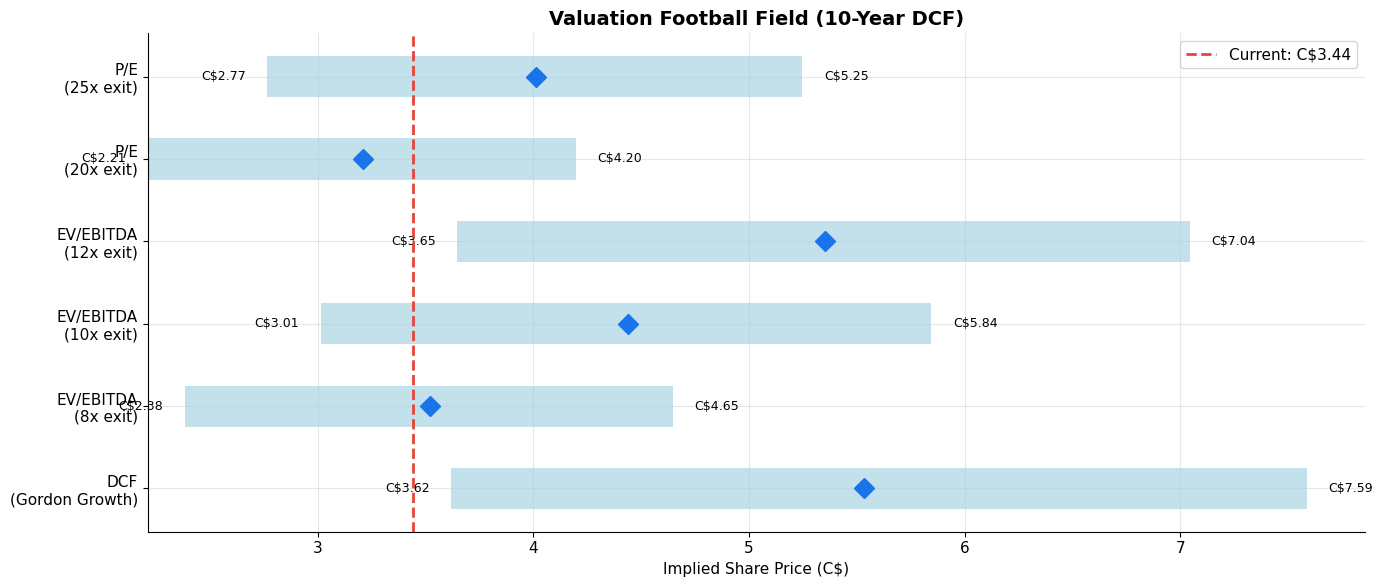

In [18]:
# ============================================================
# CELL GROUP 6: SENSITIVITY ANALYSIS
# ============================================================

# ── 1) WACC vs Terminal Growth Rate Sensitivity ─────────────

wacc_range = [0.09, 0.10, 0.11, 0.12, 0.13, 0.14, 0.15]
tg_range = [0.015, 0.020, 0.025, 0.030, 0.035]

# Use 10-year FCFs (Phase 1 + Phase 2)
base_proj = projections['Base']
base_fade = fade_projections['Base']
all_years_dcf = list(base_proj.index) + list(base_fade.index)
base_fcfs = ([base_proj.loc[yr, 'FCF_Equity_K'] for yr in base_proj.index] +
             [base_fade.loc[yr, 'FCF_Equity_K'] for yr in base_fade.index])

net_debt_K = 42_000
diluted_shares = base_fade['Shares_K'].iloc[-1]

sensitivity = pd.DataFrame(index=[f'{w:.0%}' for w in wacc_range],
                            columns=[f'{tg:.1%}' for tg in tg_range])

for w in wacc_range:
    for tg in tg_range:
        # Discount FCFs
        pv_sum = sum(fcf / (1 + w) ** (i + 1) for i, fcf in enumerate(base_fcfs))

        # Terminal value
        tv = base_fcfs[-1] * (1 + tg) / (w - tg)
        pv_tv = tv / (1 + w) ** len(all_years_dcf)

        ev = pv_sum + pv_tv
        eq = ev - net_debt_K
        price = eq / diluted_shares

        sensitivity.loc[f'{w:.0%}', f'{tg:.1%}'] = f'C${price:.2f}'

print('Price Sensitivity: WACC vs Terminal Growth Rate')
print('='*60)
print('(Base case: WACC=12%, TG=2.5%)\n')
display(sensitivity)

# ── 2) Football Field Chart ──────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 6))

# Collect valuation ranges
methods = ['DCF\n(Gordon Growth)', 'EV/EBITDA\n(8x exit)', 'EV/EBITDA\n(10x exit)',
           'EV/EBITDA\n(12x exit)', 'P/E\n(20x exit)', 'P/E\n(25x exit)']

# Calculate exit multiple valuations using 2035 EBITDA and 10-year discount
discount_factor = (1 + 0.12) ** 10  # 10 years at 12% WACC

ranges = []
for name in ['Bear', 'Base', 'Bull']:
    ebitda_2035 = fade_projections[name].loc[2035, 'Adj_EBITDA_K']
    shares = fade_projections[name].loc[2035, 'Shares_K']

    # Net income estimate (rough)
    ni_2035 = ebitda_2035 * 0.35  # rough conversion

    dcf_price = dcf_results[name]['implied_price']

    ev_8x = (ebitda_2035 * 8 - net_debt_K) / shares / discount_factor * (1 + 0.12)
    ev_10x = (ebitda_2035 * 10 - net_debt_K) / shares / discount_factor * (1 + 0.12)
    ev_12x = (ebitda_2035 * 12 - net_debt_K) / shares / discount_factor * (1 + 0.12)
    pe_20x = ni_2035 * 20 / shares / discount_factor * (1 + 0.12)
    pe_25x = ni_2035 * 25 / shares / discount_factor * (1 + 0.12)

    ranges.append([dcf_price, ev_8x, ev_10x, ev_12x, pe_20x, pe_25x])

bear_vals = ranges[0]
base_vals = ranges[1]
bull_vals = ranges[2]

y_pos = np.arange(len(methods))
for i, method in enumerate(methods):
    ax.barh(i, bull_vals[i] - bear_vals[i], left=bear_vals[i],
            color=COLORS['light'], height=0.5, zorder=2, alpha=0.7)
    ax.plot(base_vals[i], i, 'D', color=COLORS['primary'], markersize=10, zorder=4)
    ax.text(bull_vals[i] + 0.1, i, f'C${bull_vals[i]:.2f}', va='center', fontsize=9)
    ax.text(bear_vals[i] - 0.1, i, f'C${bear_vals[i]:.2f}', va='center',
            ha='right', fontsize=9)

ax.axvline(x=3.44, color=COLORS['accent'], linewidth=2, linestyle='--',
           label=f'Current: C$3.44', zorder=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(methods)
ax.set_xlabel('Implied Share Price (C$)')
ax.set_title('Valuation Football Field (10-Year DCF)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [19]:
# ── 2) Scenario Summary & Peer Comparison ────────────────────

print('='*60)
print('  SCENARIO SUMMARY')
print('='*60)

scenario_summary = pd.DataFrame(index=['Bull', 'Base', 'Bear'])
for name in ['Bull', 'Base', 'Bear']:
    p = projections[name]
    fp = fade_projections[name]
    scenario_summary.loc[name, 'FY2030 Stores'] = p.loc[2030, 'Stores']
    scenario_summary.loc[name, 'FY2030 Revenue (C$M)'] = p.loc[2030, 'Revenue_K'] / 1000
    scenario_summary.loc[name, 'FY2030 Adj EBITDA (C$M)'] = p.loc[2030, 'Adj_EBITDA_K'] / 1000
    scenario_summary.loc[name, 'FY2030 EBITDA Margin %'] = p.loc[2030, 'EBITDA_Margin_pct']
    scenario_summary.loc[name, 'FY2030 FCF (C$M)'] = p.loc[2030, 'FCF_Equity_K'] / 1000
    scenario_summary.loc[name, 'FY2035 Revenue (C$M)'] = fp.loc[2035, 'Revenue_K'] / 1000
    scenario_summary.loc[name, 'FY2035 EBITDA Margin %'] = fp.loc[2035, 'EBITDA_Margin_pct']
    scenario_summary.loc[name, 'FY2035 FCF (C$M)'] = fp.loc[2035, 'FCF_Equity_K'] / 1000
    scenario_summary.loc[name, 'Terminal WL %'] = fp.loc[2035, 'WL_Pct']
    scenario_summary.loc[name, 'Terminal ELITE (K)'] = fp.loc[2035, 'ELITE_K']
    scenario_summary.loc[name, 'Rev CAGR 25-30 %'] = (
        (p.loc[2030, 'Revenue_K'] / 593_990) ** (1/5) - 1) * 100
    scenario_summary.loc[name, 'DCF Price (C$)'] = dcf_results[name]['implied_price']
    scenario_summary.loc[name, 'Upside vs C$3.44'] = (
        (dcf_results[name]['implied_price'] / 3.44 - 1) * 100)

display(scenario_summary.round(1))

# ── Peer Comparison ──────────────────────────────────────────
print('\n' + '='*60)
print('  PEER COMPARISON')
print('='*60)

peers = pd.DataFrame({
    'Company': ['High Tide (HITI)', 'SNDL', 'Tilray (TLRY)', 'Canopy Growth (CGC)',
                'Aurora (ACB)', 'Cronos (CRON)'],
    'Focus': ['Retail', 'Retail+LP', 'LP+Beverage', 'LP', 'LP', 'LP'],
    'LTM Rev (C$M)': [671, 920, 820, 290, 392, 120],
    'Rev Growth %': [28, 1, 3, 3, -3, 5],
    'Adj EBITDA (C$M)': [48, 28, 55, -18, -15, -10],
    'EBITDA Margin %': [7.2, 3.0, 6.7, 'Neg', 'Neg', 'Neg'],
    'Market Cap (C$M)': [302, 377, 600, 430, 210, 250],
    'EV/Rev': [0.51, 0.43, 1.0, 1.5, 0.8, 3.0],
    'EV/EBITDA': ['7.1x', '15x+', '14x', 'Neg', 'Neg', 'Neg'],
    'FCF Positive?': ['Yes', 'No', 'No', 'No', 'No', 'No'],
})
peers = peers.set_index('Company')
display(peers)

print('\nKey insight: HITI is the only pure-play cannabis retailer with consistent')
print('positive EBITDA and FCF, yet trades at the lowest EV/Revenue in the peer set.')


  SCENARIO SUMMARY


,FY2030 Stores,FY2030 Revenue (C$M),FY2030 Adj EBITDA (C$M),FY2030 EBITDA Margin %,FY2030 FCF (C$M),FY2035 Revenue (C$M),FY2035 EBITDA Margin %,FY2035 FCF (C$M),Terminal WL %,Terminal ELITE (K),Rev CAGR 25-30 %,DCF Price (C$),Upside vs C$3.44
Bull,349.0,1139.8,121.2,10.6,89.3,1367.1,12.2,127.9,22.0,1250.0,13.9,7.6,120.5
Base,341.0,1053.7,97.3,9.2,66.7,1182.4,11.0,96.5,20.0,1000.0,12.1,5.5,60.8
Bear,316.0,895.8,68.1,7.6,43.0,921.1,9.9,65.3,16.0,750.0,8.6,3.6,5.2



  PEER COMPARISON


,Focus,LTM Rev (C$M),Rev Growth %,Adj EBITDA (C$M),EBITDA Margin %,Market Cap (C$M),EV/Rev,EV/EBITDA,FCF Positive?
Company,,,,,,,,,
High Tide (HITI),Retail,671,28,48,7.2,302,0.51,7.1x,Yes
SNDL,Retail+LP,920,1,28,3.0,377,0.43,15x+,No
Tilray (TLRY),LP+Beverage,820,3,55,6.7,600,1.00,14x,No
Canopy Growth (CGC),LP,290,3,-18,Neg,430,1.50,Neg,No
Aurora (ACB),LP,392,-3,-15,Neg,210,0.80,Neg,No
Cronos (CRON),LP,120,5,-10,Neg,250,3.00,Neg,No



Key insight: HITI is the only pure-play cannabis retailer with consistent
positive EBITDA and FCF, yet trades at the lowest EV/Revenue in the peer set.


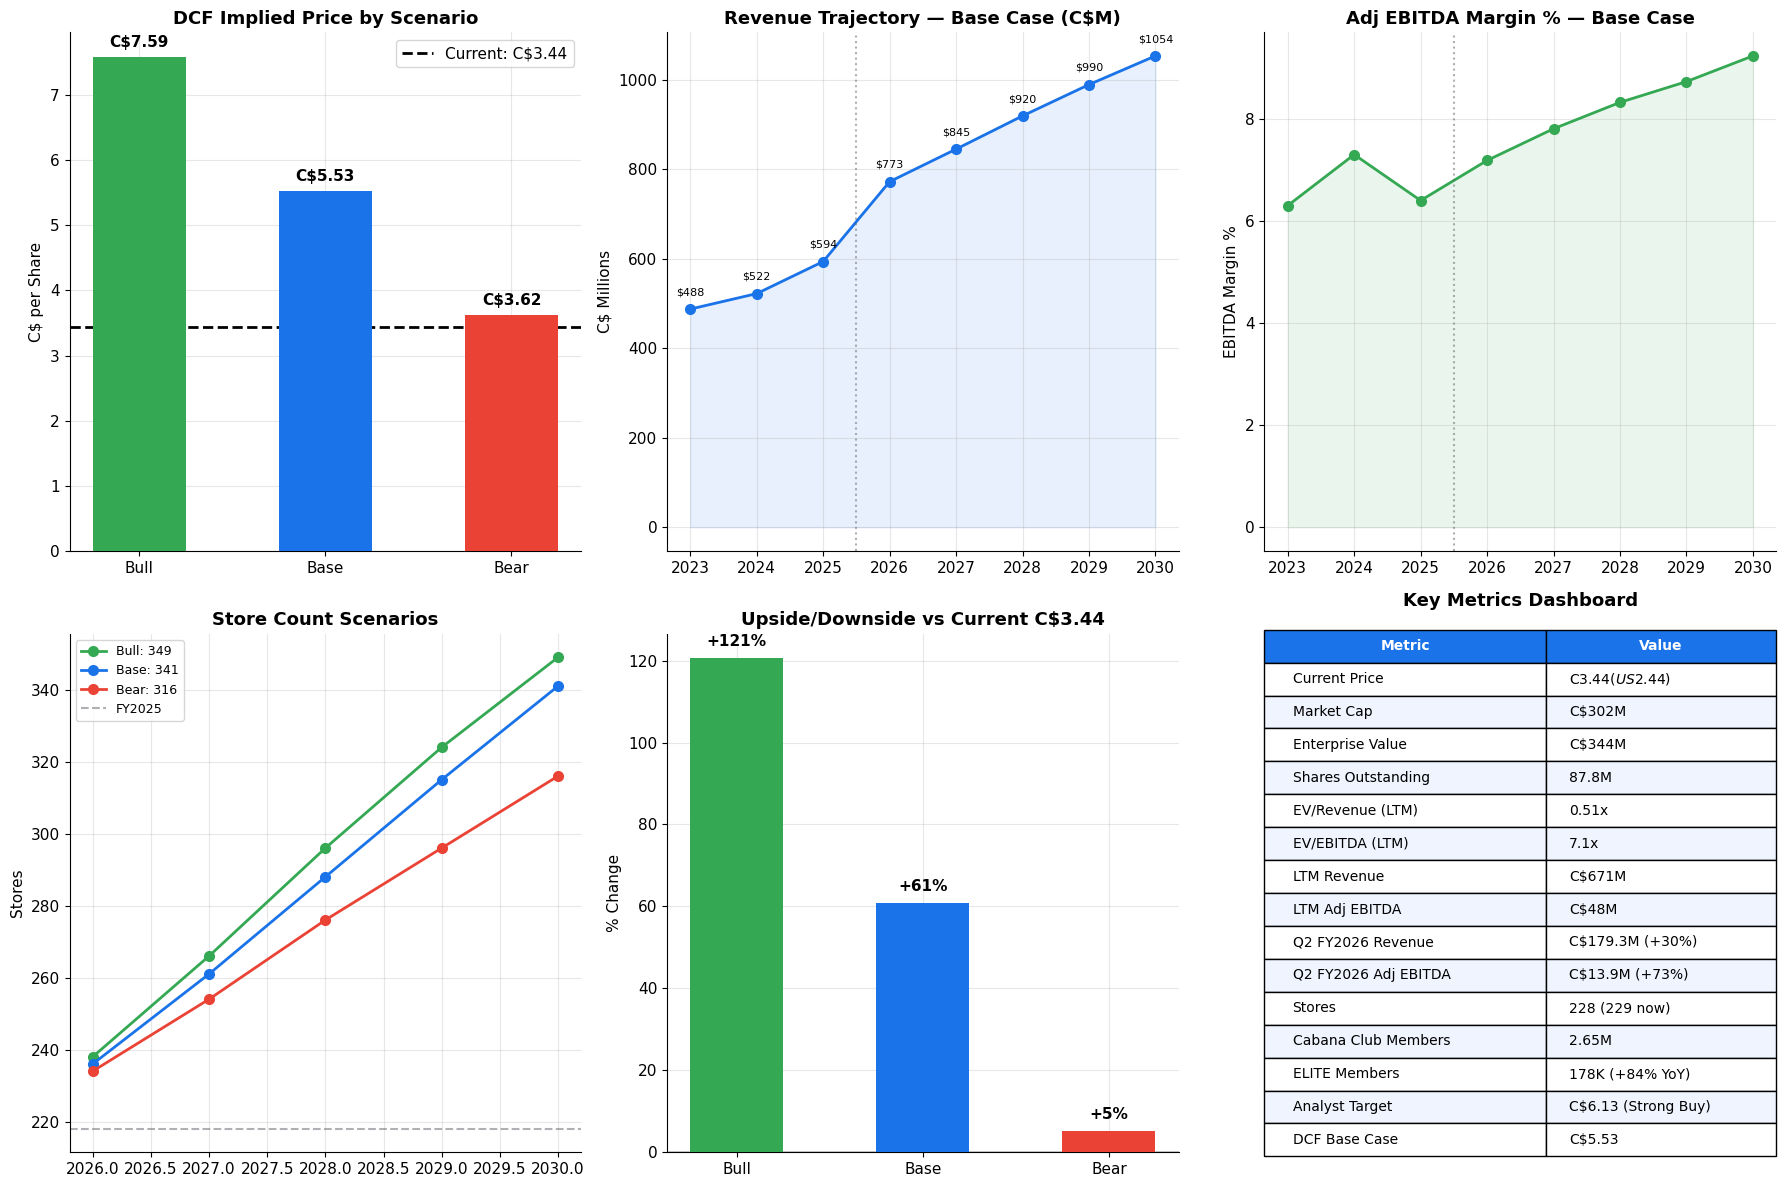


  HIGH TIDE INC. (HITI) — FINANCIAL MODEL COMPLETE
  Current Price:    C$3.44
  Bull Case DCF:    C$7.59 (+121%)
  Base Case DCF:    C$5.53 (+61%)
  Bear Case DCF:    C$3.62 (+5%)

  Analyst Consensus: C$6.13 (Strong Buy, 2 analysts)
  Risk/Reward:       Asymmetric to the upside at current levels


In [20]:
# ── 3) Key Metrics Dashboard & Final Output ──────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Current price
CURRENT_PRICE = 3.44  # C$3.44 (US$2.44) as of June 16, 2026

# --- 1. DCF Implied Prices ---
ax = axes[0, 0]
names = ['Bull', 'Base', 'Bear']
prices = [dcf_results[n]['implied_price'] for n in names]
colors_bar = [COLORS['secondary'], COLORS['primary'], COLORS['accent']]
bars = ax.bar(names, prices, color=colors_bar, width=0.5, zorder=3)
ax.axhline(y=CURRENT_PRICE, color='black', linewidth=2, linestyle='--',
           label=f'Current: C${CURRENT_PRICE}')
for bar, price in zip(bars, prices):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'C${price:.2f}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('DCF Implied Price by Scenario', fontsize=13, fontweight='bold')
ax.set_ylabel('C$ per Share')
ax.legend()

# --- 2. Revenue Growth Trajectory ---
ax = axes[0, 1]
hist_years = [2023, 2024, 2025]
hist_rev = [487.7, 522.3, 594.0]
base_rev = [projections['Base'].loc[yr, 'Revenue_K']/1000 for yr in proj_years]
all_years_plot = hist_years + proj_years
all_rev = hist_rev + base_rev
ax.plot(all_years_plot, all_rev, 'o-', color=COLORS['primary'], linewidth=2, markersize=7)
ax.fill_between(all_years_plot, all_rev, alpha=0.1, color=COLORS['primary'])
ax.axvline(x=2025.5, color=COLORS['neutral'], linestyle=':', alpha=0.5)
ax.set_title('Revenue Trajectory — Base Case (C$M)', fontsize=13, fontweight='bold')
ax.set_ylabel('C$ Millions')
for x, y in zip(all_years_plot, all_rev):
    ax.annotate(f'${y:.0f}', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=8)

# --- 3. EBITDA Margin Expansion ---
ax = axes[0, 2]
hist_margin = [6.3, 7.3, 6.4]
base_margin = [projections['Base'].loc[yr, 'EBITDA_Margin_pct'] for yr in proj_years]
ax.plot(all_years_plot, hist_margin + base_margin, 'o-',
        color=COLORS['secondary'], linewidth=2, markersize=7)
ax.fill_between(all_years_plot, hist_margin + base_margin, alpha=0.1,
                color=COLORS['secondary'])
ax.axvline(x=2025.5, color=COLORS['neutral'], linestyle=':', alpha=0.5)
ax.set_title('Adj EBITDA Margin % — Base Case', fontsize=13, fontweight='bold')
ax.set_ylabel('EBITDA Margin %')

# --- 4. Store Count All Scenarios ---
ax = axes[1, 0]
for name, color in zip(names, colors_bar):
    stores = [projections[name].loc[yr, 'Stores'] for yr in proj_years]
    ax.plot(proj_years, stores, 'o-', color=color, linewidth=2,
            markersize=7, label=f'{name}: {stores[-1]:.0f}')
ax.axhline(y=218, color=COLORS['neutral'], linestyle='--', alpha=0.5, label='FY2025')
ax.set_title('Store Count Scenarios', fontsize=13, fontweight='bold')
ax.set_ylabel('Stores')
ax.legend(fontsize=9)

# --- 5. Upside/Downside to Current Price ---
ax = axes[1, 1]
upside = [(p / CURRENT_PRICE - 1) * 100 for p in prices]
bars = ax.bar(names, upside, color=colors_bar, width=0.5, zorder=3)
ax.axhline(y=0, color='black', linewidth=1)
for bar, u in zip(bars, upside):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (3 if u > 0 else -8),
            f'{u:+.0f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Upside/Downside vs Current C$3.44', fontsize=13, fontweight='bold')
ax.set_ylabel('% Change')

# --- 6. Key Metrics Summary Table ---
ax = axes[1, 2]
ax.axis('off')
table_data = [
    ['Current Price', f'C${CURRENT_PRICE} (US$2.44)'],
    ['Market Cap', 'C$302M'],
    ['Enterprise Value', 'C$344M'],
    ['Shares Outstanding', '87.8M'],
    ['EV/Revenue (LTM)', '0.51x'],
    ['EV/EBITDA (LTM)', '7.1x'],
    ['LTM Revenue', 'C$671M'],
    ['LTM Adj EBITDA', 'C$48M'],
    ['Q2 FY2026 Revenue', 'C$179.3M (+30%)'],
    ['Q2 FY2026 Adj EBITDA', 'C$13.9M (+73%)'],
    ['Stores', '228 (229 now)'],
    ['Cabana Club Members', '2.65M'],
    ['ELITE Members', '178K (+84% YoY)'],
    ['Analyst Target', 'C$6.13 (Strong Buy)'],
    ['DCF Base Case', f'C${dcf_results["Base"]["implied_price"]:.2f}'],
]
table = ax.table(cellText=table_data,
                 colLabels=['Metric', 'Value'],
                 cellLoc='left', loc='center',
                 colWidths=[0.55, 0.45])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)
for i in range(len(table_data) + 1):
    for j in range(2):
        cell = table[i, j]
        if i == 0:
            cell.set_facecolor(COLORS['primary'])
            cell.set_text_props(color='white', fontweight='bold')
        elif i % 2 == 0:
            cell.set_facecolor('#f0f4ff')
ax.set_title('Key Metrics Dashboard', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print('\n' + '='*60)
print('  HIGH TIDE INC. (HITI) — FINANCIAL MODEL COMPLETE')
print('='*60)
print(f'  Current Price:    C${CURRENT_PRICE}')
print(f'  Bull Case DCF:    C${dcf_results["Bull"]["implied_price"]:.2f} '
      f'({(dcf_results["Bull"]["implied_price"]/CURRENT_PRICE-1)*100:+.0f}%)')
print(f'  Base Case DCF:    C${dcf_results["Base"]["implied_price"]:.2f} '
      f'({(dcf_results["Base"]["implied_price"]/CURRENT_PRICE-1)*100:+.0f}%)')
print(f'  Bear Case DCF:    C${dcf_results["Bear"]["implied_price"]:.2f} '
      f'({(dcf_results["Bear"]["implied_price"]/CURRENT_PRICE-1)*100:+.0f}%)')
print(f'\n  Analyst Consensus: C$6.13 (Strong Buy, 2 analysts)')
print(f'  Risk/Reward:       Asymmetric to the upside at current levels')